<a href="https://colab.research.google.com/github/Jgom3z/MachineLearning/blob/main/Week_03/WorkShop/Entregable_2_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Entregable 2 – Machine Learning

## Comparación de modelos de regresión y clasificación

### Modelos obligatorios
- Regresión lineal
- Regresión logística
- KNN
- Naive Bayes

## Objetivo
Analizar el dataset seleecionado por el equipo a inicio del curso , preparar los datos, entrenar varios modelos y justificar cuál resulta más adecuado según el problema y los resultados obtenidos.


## Instrucciones generales

Cada grupo debe trabajar con un dataset diferente o con una variante diferente del problema.

El trabajo debe incluir:

1. Entendimiento del problema  
2. Exploración de datos  
3. Preparación de datos  
4. Implementación de modelos  
5. Evaluación  
6. Comparación de resultados  
7. Conclusiones  
8. Experimentos adicionales  
9. Predicción manual o caso nuevo  
10. Explicación conceptual

> No se evaluará solo que el código funcione, sino la capacidad de **explicar, justificar e interpretar**.


## 1. Información del equipo

Completa esta sección con los datos del grupo.


In [ ]:
# Nombres de los integrantes:
# 1.Julian Gomez Posada
# 2.Laura Posada
# 3.Samuel Gil lopez

# Dataset seleccionado: shopping_behavior_updated
# https://www.kaggle.com/datasets/saadaliyaseen/shopping-behaviour-dataset?resource=download
# Problema que desean resolver:
#¿Podríamos predecir cuánto dinero gastará un cliente en una compra futura basándonos en sus características o en compras anteriores?

# Tipo de problema (regresión / clasificación):
#Regresion

## 2. Carga de librerías

En este bloque deben importarse las librerías necesarias para desarrollar el trabajo.


In [1]:
# Importa aquí las librerías necesarias.
# Ejemplo:
import pandas as pd
import numpy as np

from scipy.stats import chi2_contingency
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (mean_squared_error, r2_score,
                             accuracy_score, classification_report, confusion_matrix, mean_absolute_error)

from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

import matplotlib.pyplot as plt
import seaborn as sns

## 3. Cargar el dataset

En este bloque deben cargar el dataset seleccionado y mostrar una vista inicial de los datos.


In [2]:
# Carga aquí tu dataset.
# Ejemplo:
df = pd.read_csv("/content/shopping_behavior_updated (1).csv")

print("Primeras filas:")
display(df.head(5))
print()

print("Ultimas filas:")
print(df.tail(3))
print()


Primeras filas:


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually



Ultimas filas:
      Customer ID  Age  Gender Item Purchased     Category  \
3897         3898   46  Female           Belt  Accessories   
3898         3899   44  Female          Shoes     Footwear   
3899         3900   52  Female        Handbag  Accessories   

      Purchase Amount (USD)    Location Size  Color  Season  Review Rating  \
3897                     33  New Jersey    L  Green  Spring            2.9   
3898                     77   Minnesota    S  Brown  Summer            3.8   
3899                     81  California    M  Beige  Spring            3.1   

     Subscription Status Shipping Type Discount Applied Promo Code Used  \
3897                  No      Standard               No              No   
3898                  No       Express               No              No   
3899                  No  Store Pickup               No              No   

      Previous Purchases Payment Method Frequency of Purchases  
3897                  24          Venmo              Qua

### Interpretación

Describe brevemente:
- qué contiene el dataset:
    El conjunto de datos registra el comportamiento de compra de los clientes en función de diferentes características demográficas y atributos de compra.
    Incluye información sobre los artículos comprados, el gasto, los antecedentes del cliente y sus preferencias de compra.
    Los datos ayudan a analizar las tendencias de consumo, los patrones de compra y el comportamiento estacional.
    
- cuántas filas y columnas tiene:
    El dataset tiene un total de 3900 filas y 18 columnas

- qué representa cada registro: Cada registro en la base de datos representa  una compra realizada

1. ID de cliente : identificador único para cada cliente.

2. Edad: Edad del cliente en años.

3. Género : Indica si el cliente es masculino o femenino.

4. Artículo comprado : El producto específico que compró el cliente.

5. Categoría: Categoría de producto como ropa, calzado, etc.

6. Importe de la compra (USD) : importe total gastado en dólares estadounidenses.

7. Ubicación : Indique dónde realizó la compra el cliente.

8. Talla: Talla de la prenda/calzado comprado.

9. Color: Color del artículo comprado.

10. Temporada: Temporada en la que se realizó la compra.

11. Calificación de la reseña : Calificación numérica que el cliente otorga a su experiencia de compra.

12. Estado de la suscripción : indica si el cliente está suscrito (Sí/No).

13. Tipo de envío : método utilizado para enviar el pedido.

14. Descuento aplicado : si se aplicó algún descuento.

15. Código promocional utilizado : Indica si se aplicó algún código promocional.

16. Compras anteriores : número de compras históricas realizadas por el cliente.

17. Método de pago : modo de pago utilizado para la transacción.

18. Frecuencia de compra : con qué frecuencia el cliente realiza compras.




## 4. Entendimiento del problema

Explica con tus palabras:

- **¿Qué se quiere predecir?**
  Se quiere predecir el `Purchase Amount (USD)`, es decir, la cantidad de dinero que un cliente gastará en una futura compra.

- **¿Por qué este problema es importante?**
  Predecir el monto de compra futuro es crucial para la gestión de inventario, estrategias de precios, campañas de marketing personalizadas y para identificar clientes de alto valor. Permite a la empresa anticipar ingresos y optimizar sus operaciones.

- **¿Se trata de regresión o clasificación?**
  Dado que la variable objetivo `Purchase Amount (USD)` es una cantidad numérica continua, se trata de un problema de **regresión**.

- **¿Qué variable será la variable objetivo?**
  La variable objetivo será `Purchase Amount (USD)`.

## 5. Exploración de datos (EDA)

En esta sección deben explorar el dataset:
- tipos de datos
- valores nulos
- estadísticas descriptivas
- visualizaciones
- relación entre variables


In [3]:
print("Dimensiones (filas, columnas):", df.shape)
display("Columnas:", list(df.columns))
print()

print("Tipos de datos y nulos:")
display(df.info())
print()

print("Valores nulos por columna:")
display(df.isnull().sum())
print()

print("Resumen numerico (media, desv, min, max, cuartiles) excluyendo 'Customer ID':")
display(df.drop(columns=['Customer ID']).describe())
print()

print("Resumen de categorias (valores unicos, frecuencia) para columnas object:")
display(df.describe(include='object'))
print()

print("Categorias de producto (valores unicos):")
display(df['Category'].unique())
print()

print("Items comprados (valores unicos):")
display(df['Item Purchased'].unique())
print()

print("Localizaciones (valores unicos):")
display(df['Location'].unique())
print()

print("Tallas (valores unicos):")
display(df['Size'].unique())
print()

print("Colores (valores unicos):")
display(df['Color'].unique())
print()

print("Temporadas (valores unicos):")
display(df['Season'].unique())
print()

print("Metodos de pago (valores unicos):")
display(df['Payment Method'].unique())
print()

print("Frecuencia de compra (valores unicos):")
display(df['Frequency of Purchases'].unique())
print()




Dimensiones (filas, columnas): (3900, 18)


'Columnas:'

['Customer ID',
 'Age',
 'Gender',
 'Item Purchased',
 'Category',
 'Purchase Amount (USD)',
 'Location',
 'Size',
 'Color',
 'Season',
 'Review Rating',
 'Subscription Status',
 'Shipping Type',
 'Discount Applied',
 'Promo Code Used',
 'Previous Purchases',
 'Payment Method',
 'Frequency of Purchases']


Tipos de datos y nulos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3900 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used

None

...

array(['Winter', 'Spring', 'Summer', 'Fall'], dtype=object)


Metodos de pago (valores unicos):


array(['Venmo', 'Cash', 'Credit Card', 'PayPal', 'Bank Transfer',
       'Debit Card'], dtype=object)


Frecuencia de compra (valores unicos):


array(['Fortnightly', 'Weekly', 'Annually', 'Quarterly', 'Bi-Weekly',
       'Monthly', 'Every 3 Months'], dtype=object)

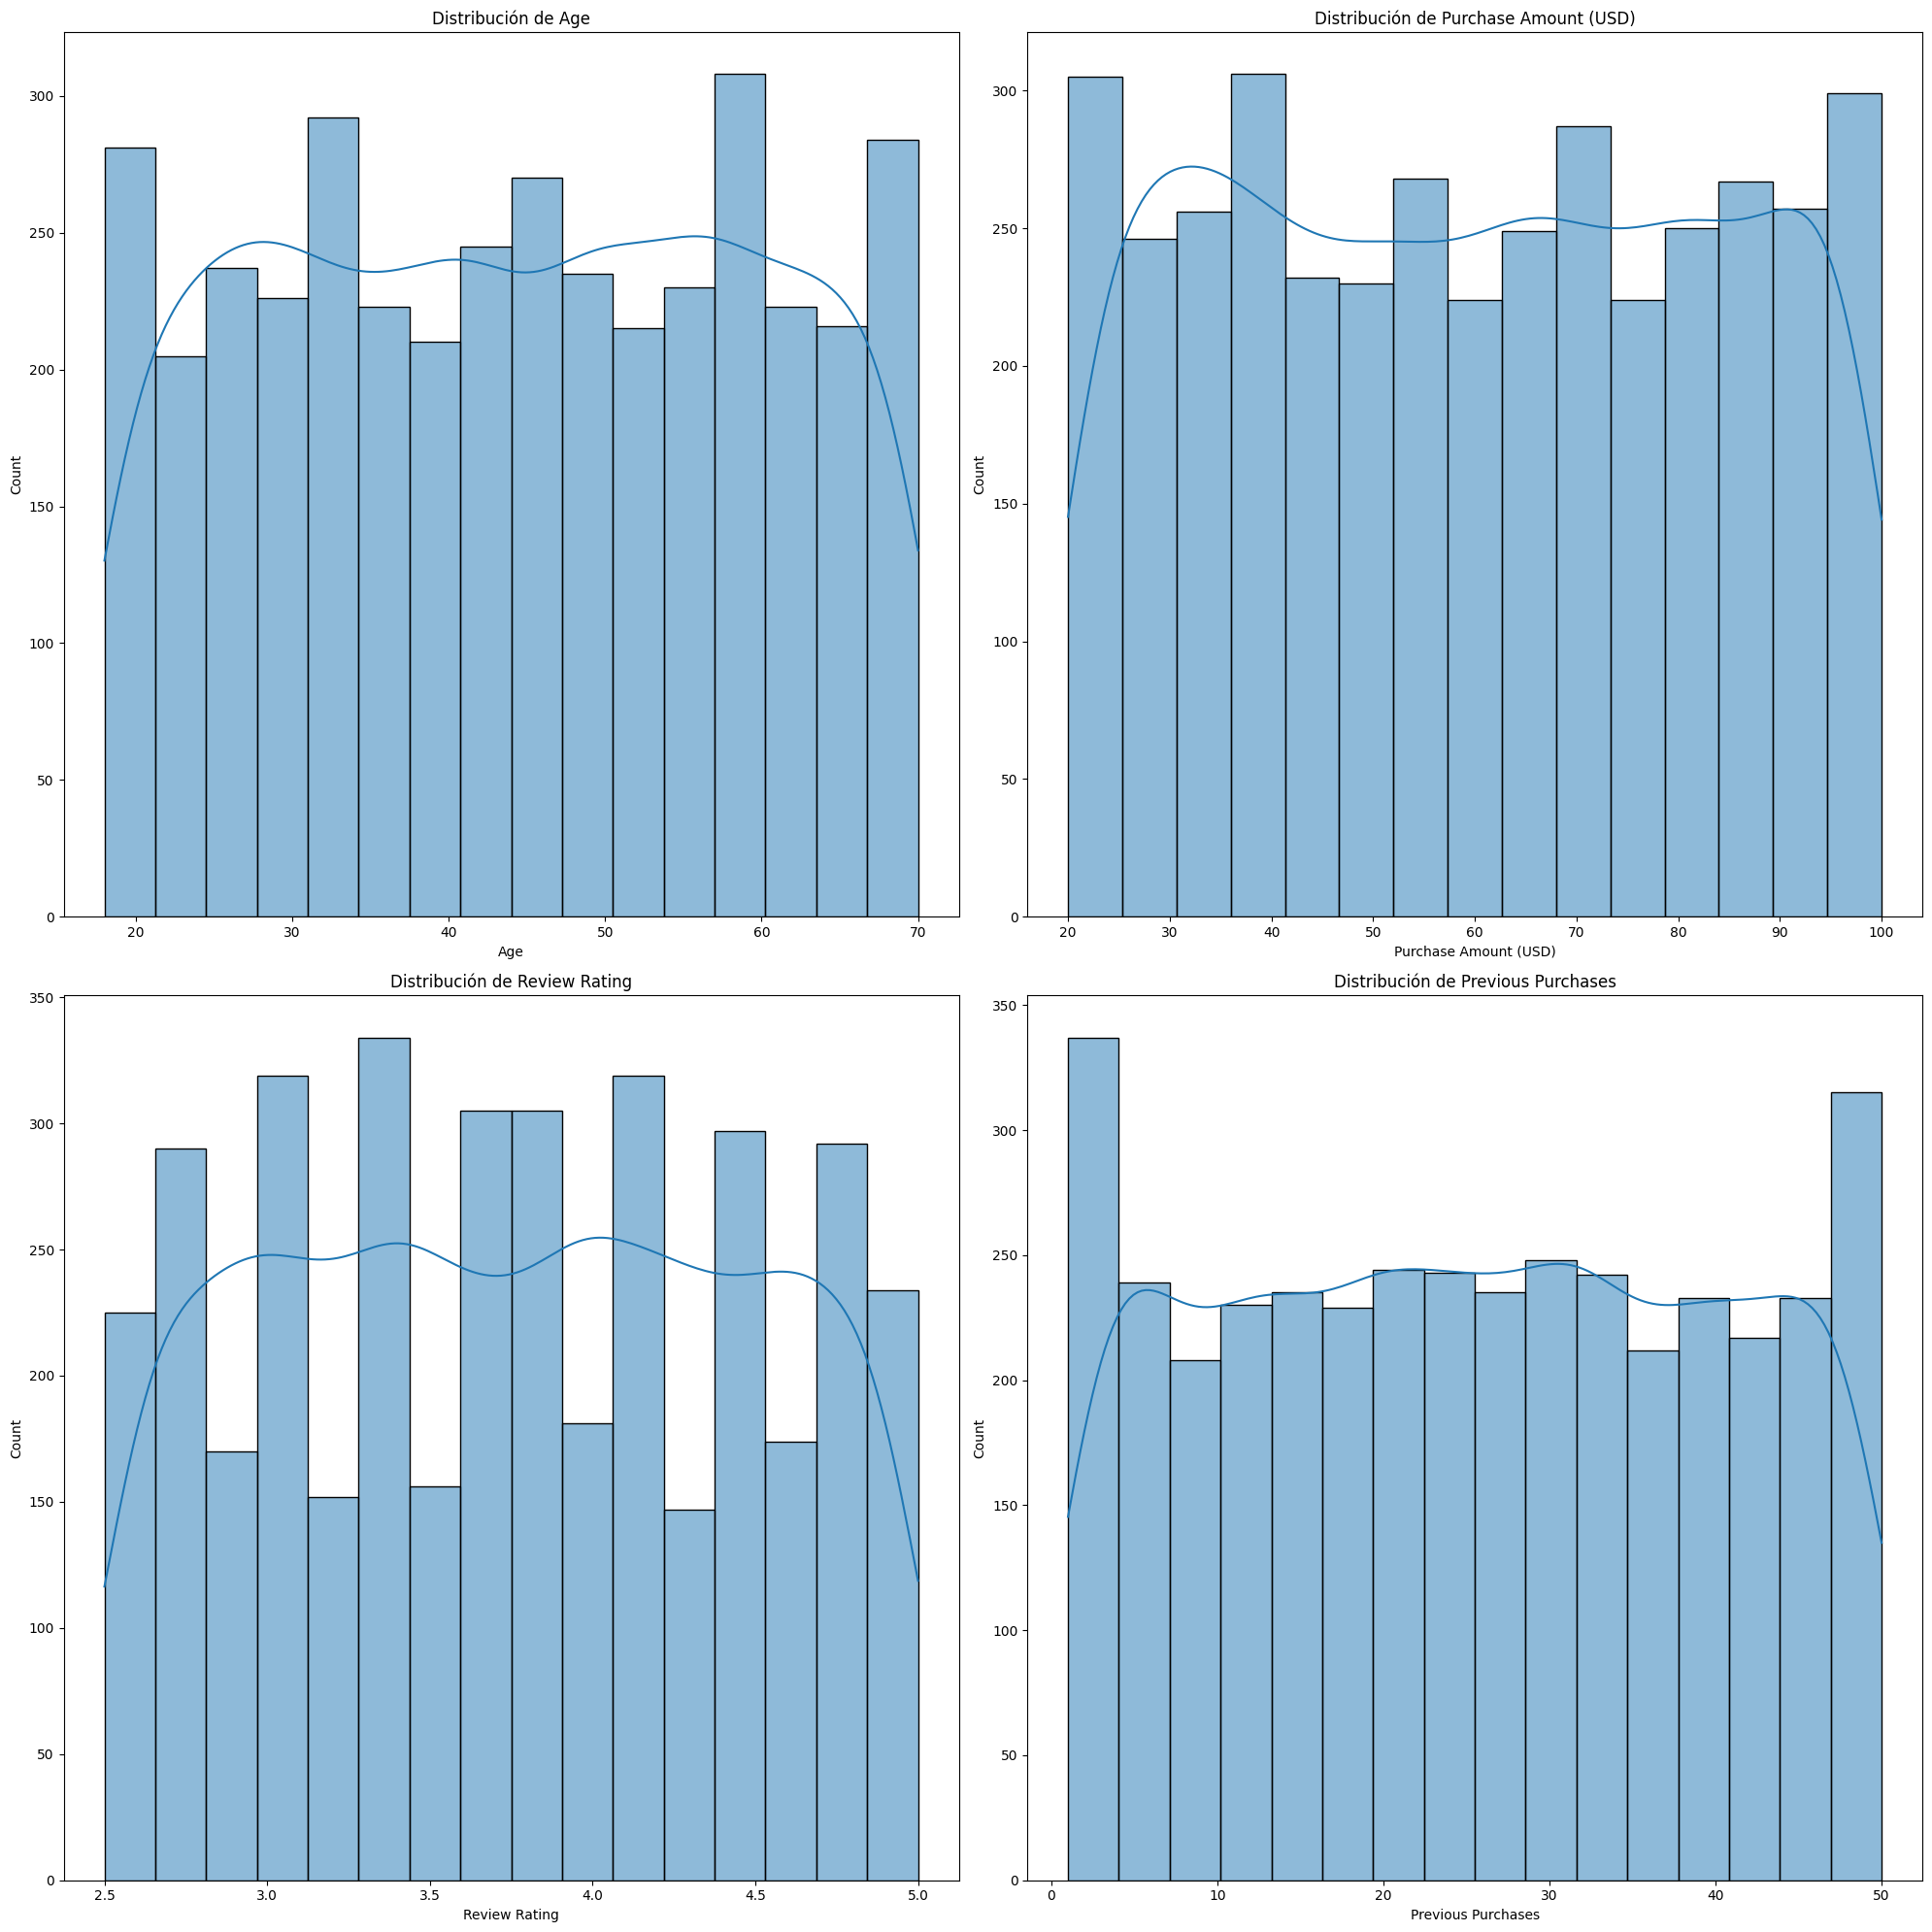

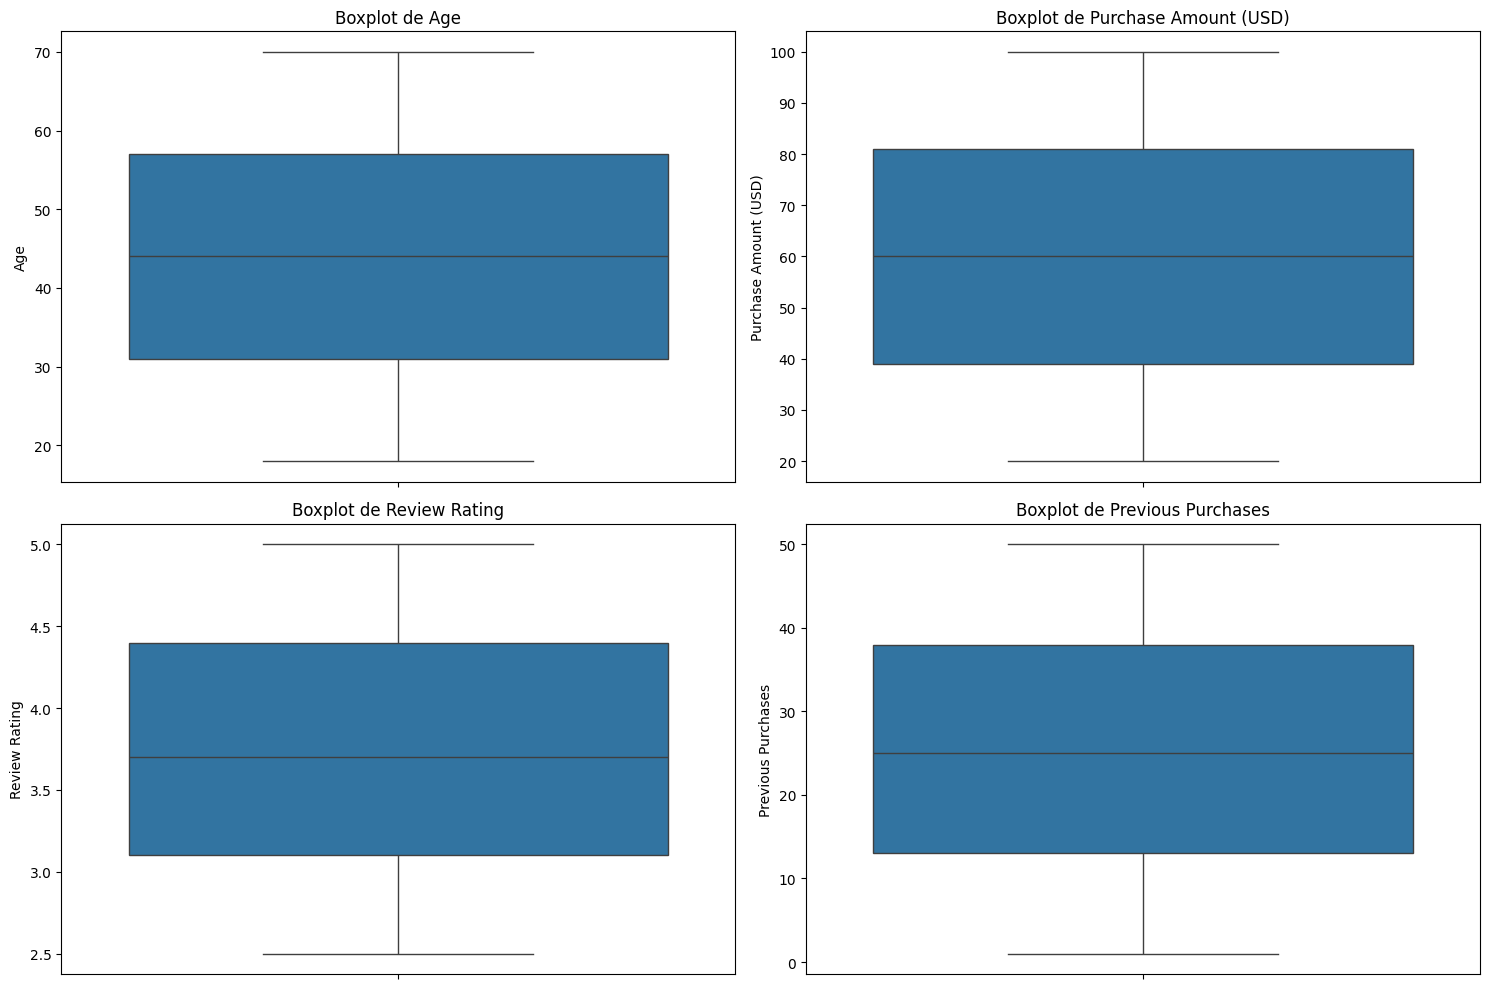

In [ ]:
# Histograms para variables numéricas
plt.figure(figsize=(20, 20))
num_cols = ['Age', 'Purchase Amount (USD)', 'Review Rating', 'Previous Purchases']
for i, col in enumerate(num_cols):
    plt.subplot(2, 2, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribución de {col}')
plt.tight_layout()
plt.show()

#boxplot para variables numericas
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot de {col}')
plt.tight_layout()
plt.show()

### Distribución de variables categóricas y binarias

/tmp/ipykernel_1688/2613098165.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order = df[col].value_counts().index, palette='viridis')
/tmp/ipykernel_1688/2613098165.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order = df[col].value_counts().index, palette='viridis')
/tmp/ipykernel_1688/2613098165.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order = df[col].value_counts().index, palette='viridis')
/tmp/ipykernel_1688/2613098165.py:6: FutureWarning: 

Passing `palette` without assignin

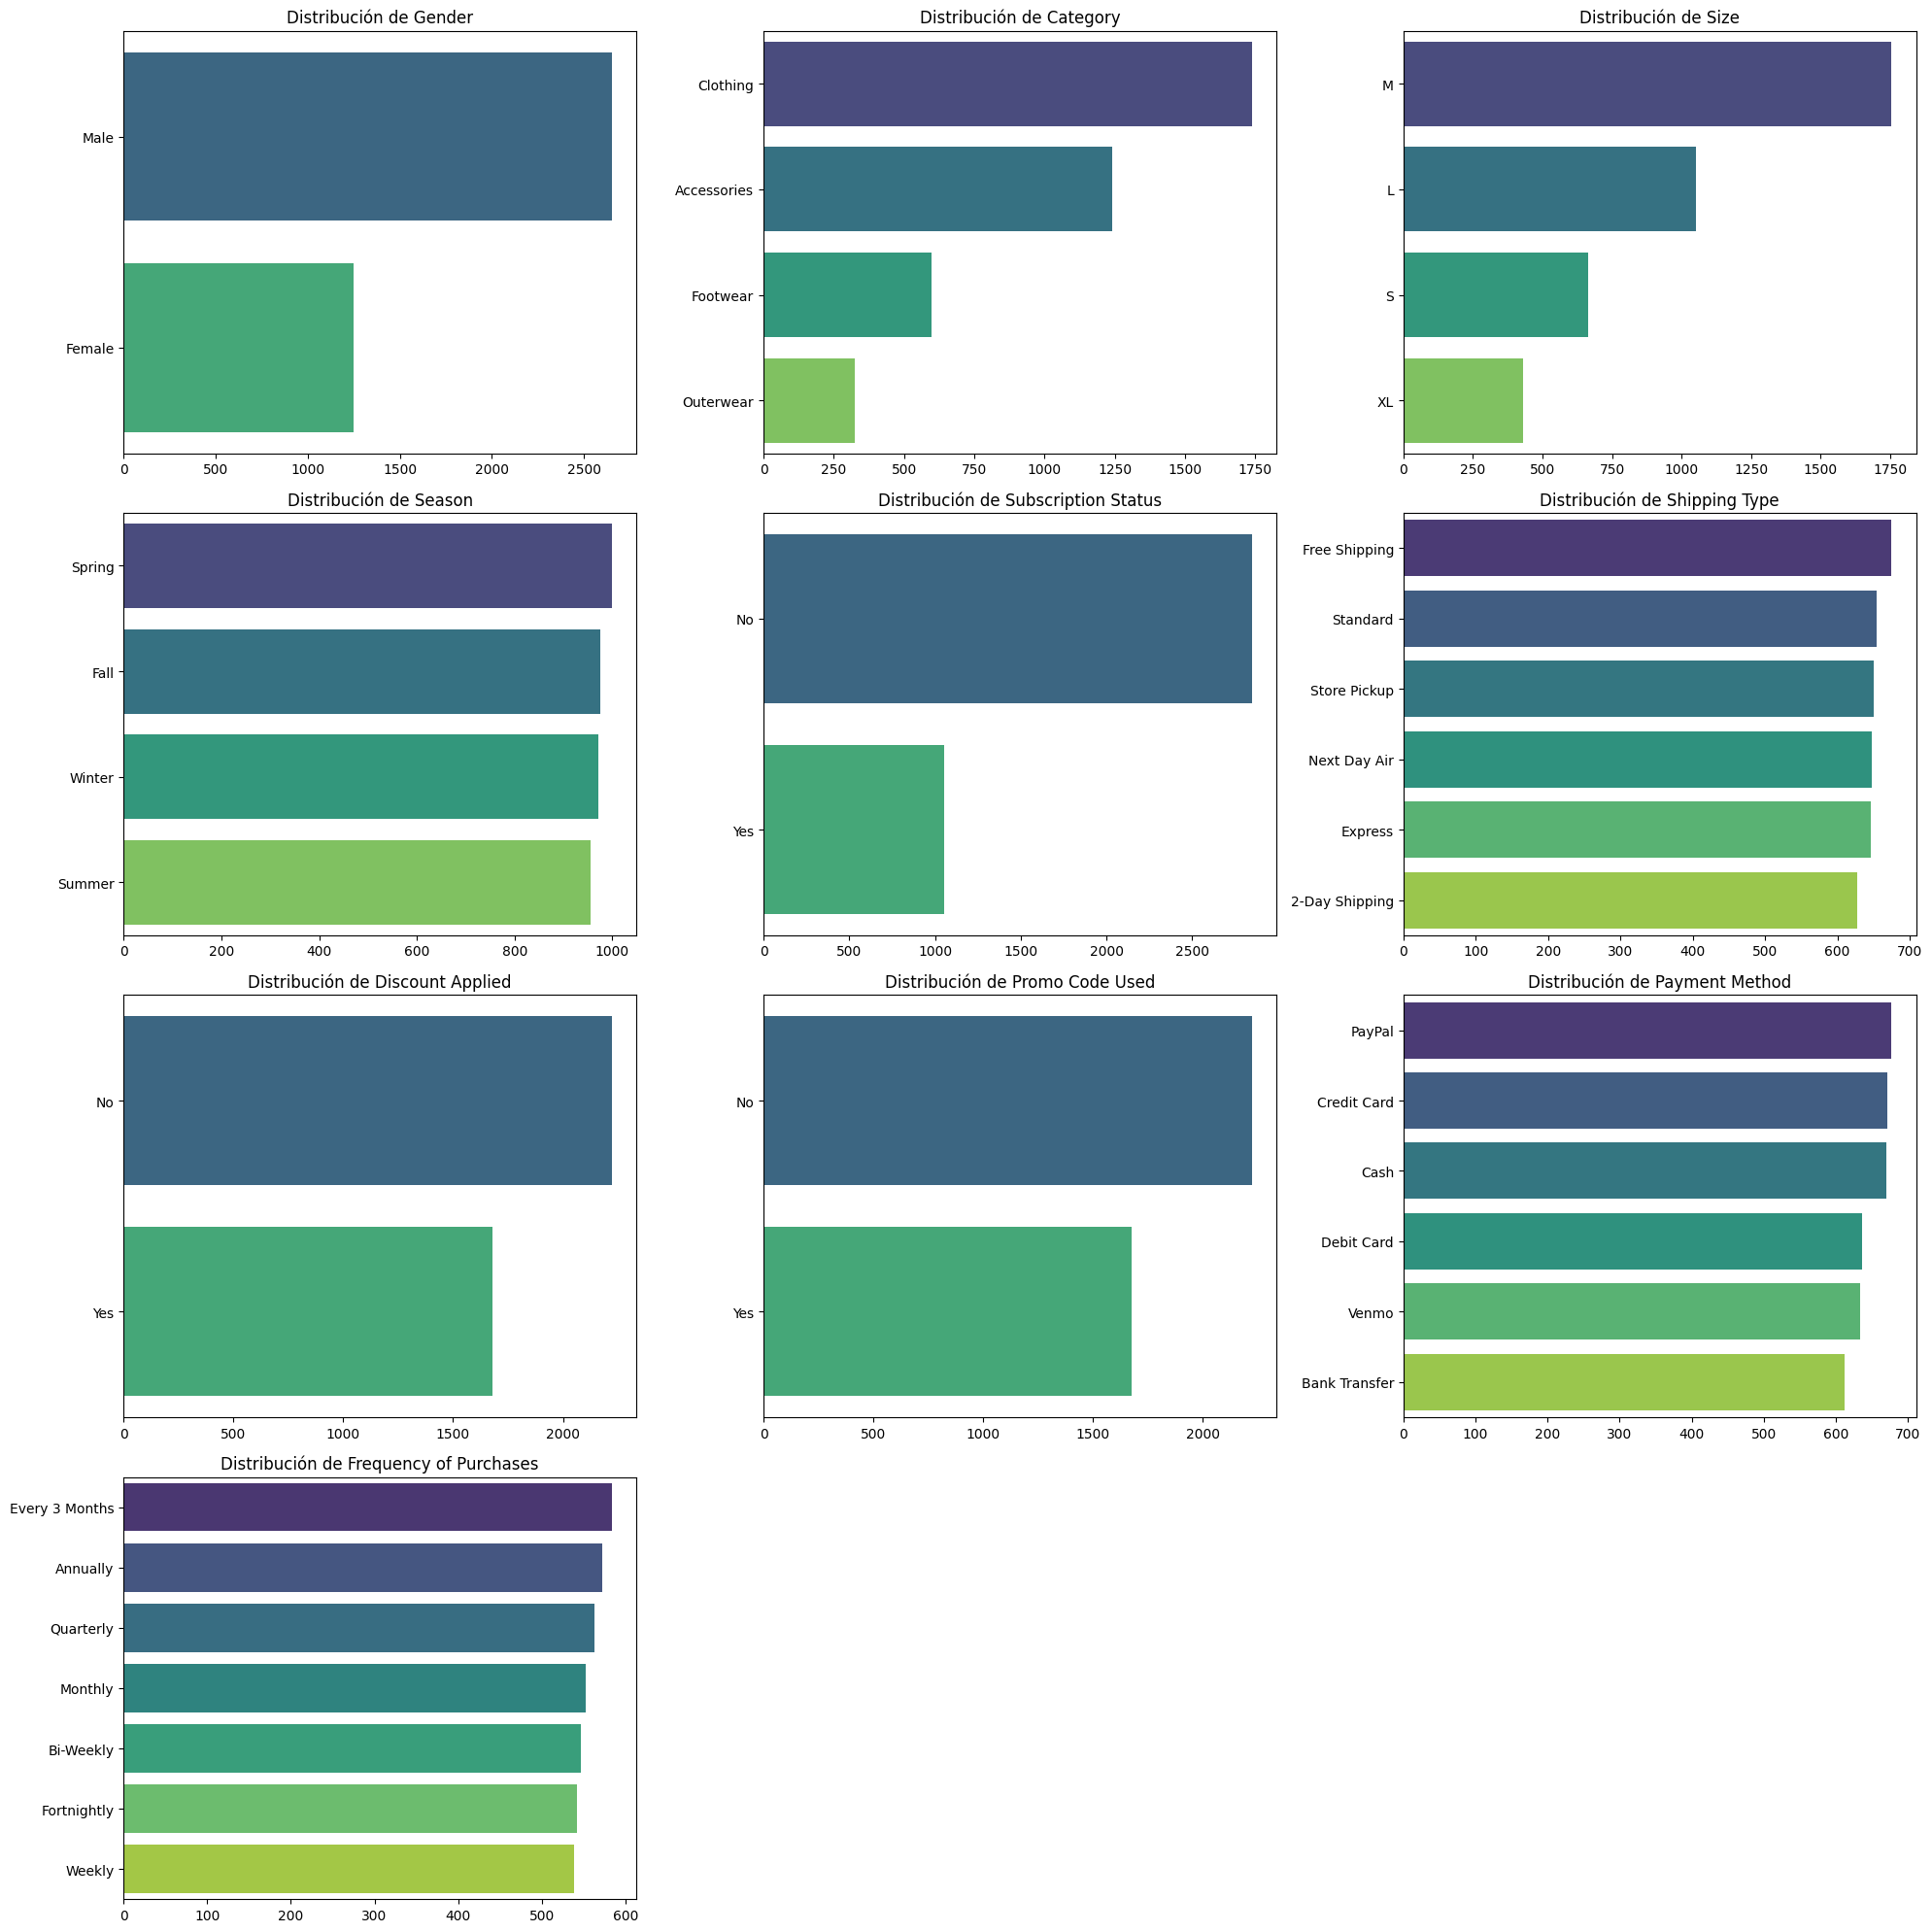

/tmp/ipykernel_1688/2613098165.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df['Item Purchased'], order=df['Item Purchased'].value_counts().head(10).index, palette='plasma')
/tmp/ipykernel_1688/2613098165.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df['Location'], order=df['Location'].value_counts().head(10).index, palette='magma')


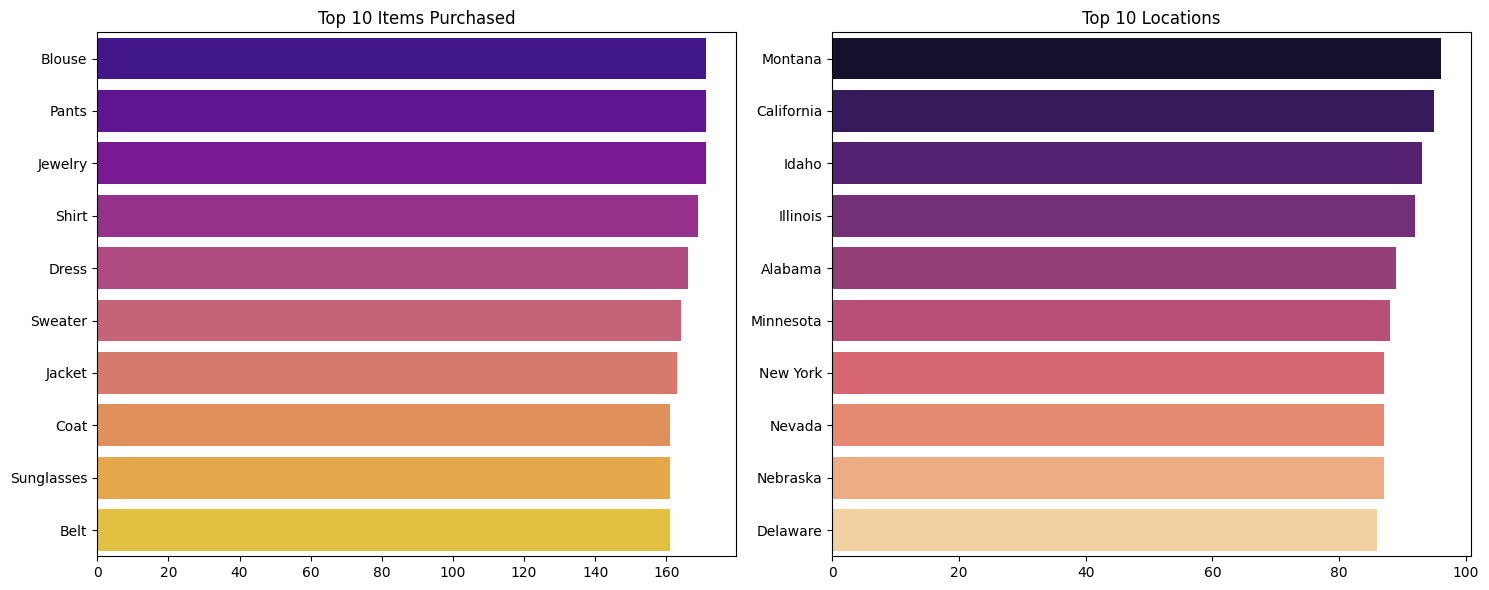

In [ ]:
# Count plots para variables categóricas y binarias
plt.figure(figsize=(20, 20))
cat_cols = ['Gender', 'Category', 'Size', 'Season', 'Subscription Status', 'Shipping Type', 'Discount Applied', 'Promo Code Used', 'Payment Method', 'Frequency of Purchases']
for i, col in enumerate(cat_cols):
    plt.subplot(4, 3, i + 1)
    sns.countplot(y=df[col], order = df[col].value_counts().index, palette='viridis')
    plt.title(f'Distribución de {col}')
    plt.xlabel('')
    plt.ylabel('')
plt.tight_layout()
plt.show()


# Para 'Item Purchased' y 'Location' que tienen muchas categorías, podemos visualizar las top N
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
sns.countplot(y=df['Item Purchased'], order=df['Item Purchased'].value_counts().head(10).index, palette='plasma')
plt.title('Top 10 Items Purchased')
plt.xlabel('')
plt.ylabel('')

plt.subplot(1, 2, 2)
sns.countplot(y=df['Location'], order=df['Location'].value_counts().head(10).index, palette='magma')
plt.title('Top 10 Locations')
plt.xlabel('')
plt.ylabel('')
plt.tight_layout()
plt.show()

### Matriz de Correlación de Variables Numéricas

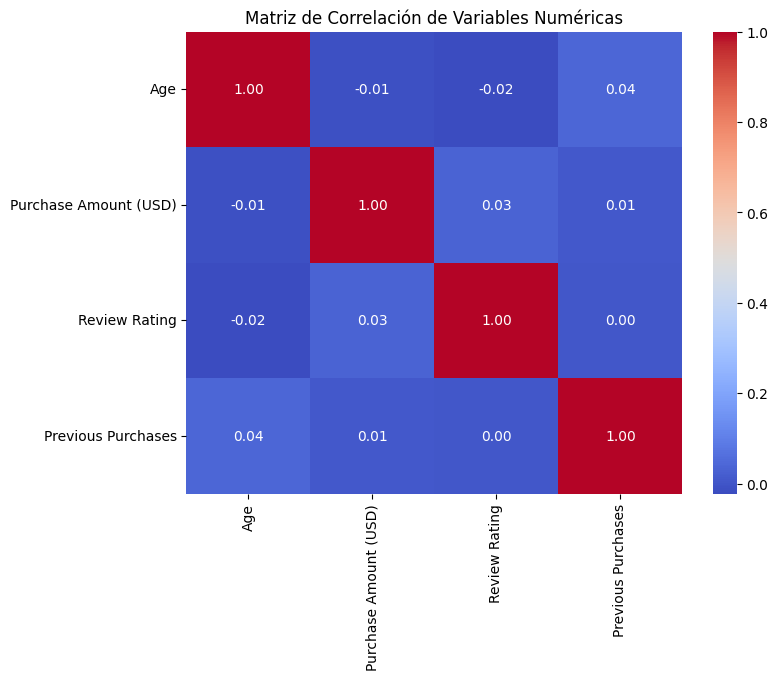

In [ ]:
# Calcular la matriz de correlación para variables numéricas
corr_matrix = df[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

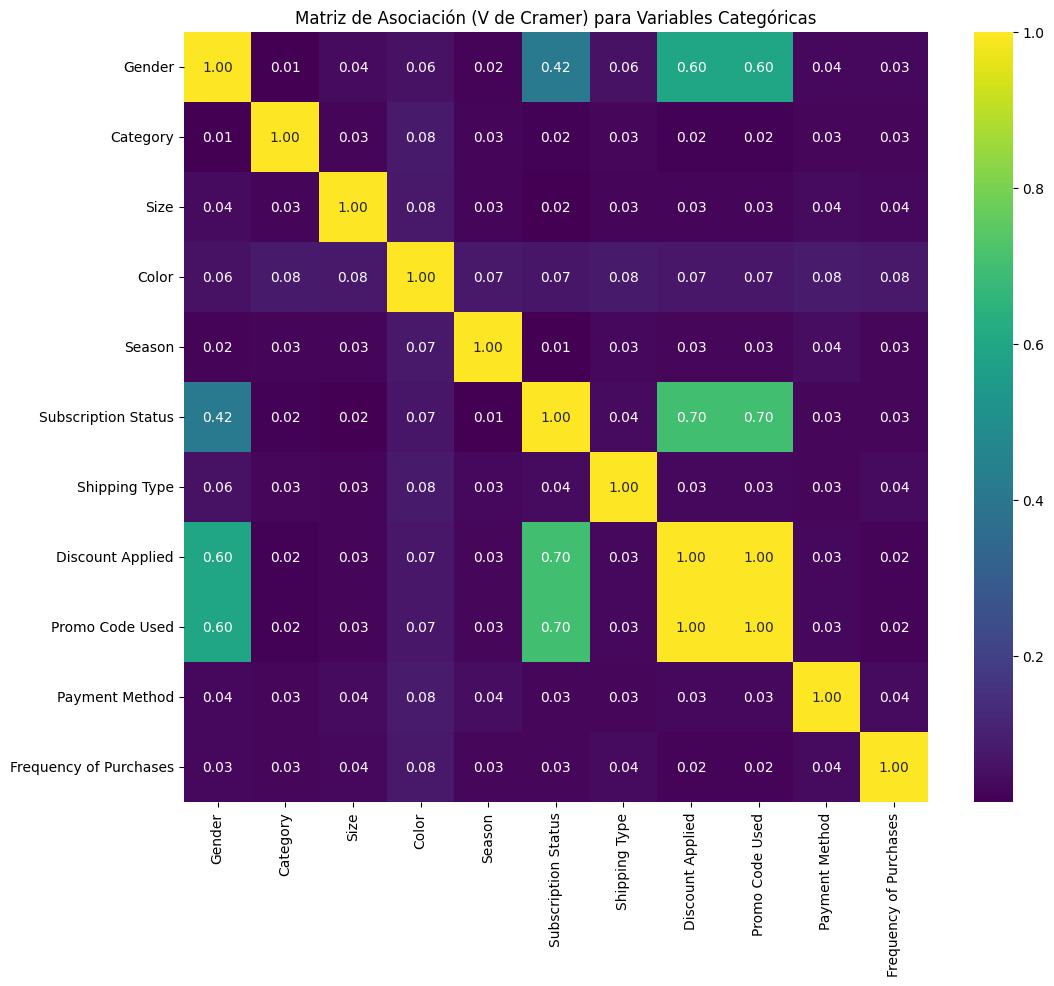

In [ ]:
def cramers_v(x, y):
    '''
    Calcula el coeficiente V de Cramer entre dos variables categóricas.
    Args:
        x (pd.Series): Primera variable categórica.
        y (pd.Series): Segunda variable categórica.
    Returns:
        float: El coeficiente V de Cramer.
    '''
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    # Handle cases where r or k is 1 to avoid division by zero or NaN
    if min(k, r) == 1:
        return 0.0  # No association can be measured if one variable has only one category
    v = np.sqrt(phi2 / min(k - 1, r - 1))
    return v

# Redefine df_processed, X, and categorical_features within this cell
# This ensures the variables are available for Cramer's V calculation
df_processed = df.drop(columns=['Customer ID', 'Location'])
target_variable = 'Item Purchased'
y = df_processed[target_variable]
X = df_processed.drop(columns=[target_variable])
categorical_features = X.select_dtypes(include='object').columns.tolist()

# Obtener las variables categóricas del DataFrame X
categorical_data = X[categorical_features]

# Crear una matriz vacía para almacenar los valores de V de Cramer
cramers_v_matrix = pd.DataFrame(index=categorical_features, columns=categorical_features)

# Calcular V de Cramer para cada par de variables categóricas
for col1 in categorical_features:
    for col2 in categorical_features:
        if col1 == col2:
            cramers_v_matrix.loc[col1, col2] = 1.0 # Una variable consigo misma tiene asociación perfecta
        else:
            cramers_v_matrix.loc[col1, col2] = cramers_v(categorical_data[col1], categorical_data[col2])

# Convertir la matriz a tipo float para el heatmap
cramers_v_matrix = cramers_v_matrix.astype(float)

# Visualizar la matriz de V de Cramer
plt.figure(figsize=(12, 10))
sns.heatmap(cramers_v_matrix, annot=True, cmap='viridis', fmt=".2f")
plt.title("Matriz de Asociación (V de Cramer) para Variables Categóricas")
plt.show()

### Interpretación

Explica qué descubriste en la exploración:
en la exploracion del dataset no se encuentran valores nulos, pero tampoco hay una correlacion relevante entre las columnas numericas, esto podra ser una problematica para realizar la regresion lineal y el modelo predictivo, una muy buena ventaja es que no se observan datos atipicos. En la correlacion de variables categoricas si se haya varias correlaciones positivas


## 6. Preparación de datos

En esta sección deben:
- limpiar datos
- transformar variables si es necesario
- seleccionar variables
- definir X e y
- dividir en entrenamiento y prueba
- escalar datos si aplica


In [12]:
df_model = df.copy()

# Eliminar columnas no útiles
df_model.drop(columns=[
    'Customer ID',
    'Item Purchased',
    'Location',
    'Color'
], inplace=True)

# Convertir target binario
df_model['Discount Applied'] = df_model['Discount Applied'].map({'Yes':1, 'No':0})

# Label Encoding para binarias
binary_cols = ['Gender', 'Subscription Status', 'Promo Code Used']
le = LabelEncoder()

for col in binary_cols:
    df_model[col] = le.fit_transform(df_model[col])

# OneHot para pocas categorías
df_model = pd.get_dummies(df_model, columns=[
    'Category', 'Season', 'Size', 'Payment Method', 'Frequency of Purchases', 'Shipping Type' # Added 'Shipping Type'
], drop_first=True)

### Interpretación

Explica:
- qué decisiones tomaste para preparar los datos,
- por qué seleccionaste esas variables,
- y si fue necesario escalar o transformar datos.

Para la preparación de los datos se realizaron las siguientes decisiones:

**NO usamos:**

* Item Purchased (demasiadas categorías)
* Location (50 estados → ruido)
* Color (demasiadas categorías)

**Usamos:**

* Category (4 valores)
* Season (4 valores)
* Size (4 valores)
* Gender
* Subscription Status
* Payment Method
* Frequency of Purchases

**Encoding inteligente** (no abusar de OneHot)
* Variables con pocas categorías → OneHot
* Variables ordinales → Label Encoding

**Escalado**
* KNN → necesita escala
* Regresión y Naive Bayes → no obligatorio

## 7. Modelo 1 – Regresión lineal

Este modelo debe usarse **solo si tu problema lo permite**.  
Si tu variable objetivo es numérica continua, puedes aplicarlo directamente.


RMSE: 23.772034100736796
R2: -0.009877426041839943


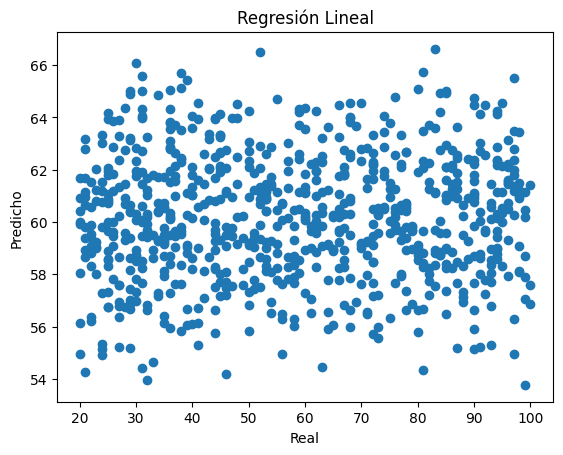

In [13]:
X_reg = df_model.drop(columns=['Purchase Amount (USD)'])
y_reg = df_model['Purchase Amount (USD)']

X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2:", r2)

plt.scatter(y_test, y_pred)
plt.xlabel("Real")
plt.ylabel("Predicho")
plt.title("Regresión Lineal")
plt.show()

### Interpretación

Este modelo sí aplica para el problema planteado, ya que la variable objetivo `Purchase Amount (USD)` es numérica y continua, lo que lo clasifica como un problema de regresión. La Regresión Lineal es un algoritmo diseñado para este tipo de tareas.

Los resultados obtenidos son los siguientes:

*   **RMSE (Root Mean Squared Error)**: Aproximadamente **23.77**. Esta métrica nos dice que, en promedio, las predicciones del modelo se desvían alrededor de $23.77 del valor real de la `Purchase Amount (USD)`. Dado que el rango de la `Purchase Amount (USD)` va de 20 a 100 (según la exploración inicial), un error de 23.77 es significativamente alto y representa una gran parte del rango total, indicando que las predicciones del modelo son bastante imprecisas.

*   **R² (Coeficiente de Determinación)**: Aproximadamente **-0.0099**. Este es el resultado más crítico. Un valor de R² negativo indica que el modelo de regresión lineal es peor que un modelo base que simplemente predice la media de la variable objetivo para todas las instancias. En otras palabras, nuestro modelo no explica casi nada de la variabilidad en el `Purchase Amount (USD)` y, de hecho, introduce más error que simplemente ignorar todas las características y adivinar el promedio.

### Desempeño del Modelo

El desempeño de este modelo de Regresión Lineal es **muy pobre**. Los resultados sugieren que las características que hemos utilizado no tienen una relación lineal fuerte con la `Purchase Amount (USD)`, o al menos, este modelo lineal simple no es capaz de capturar esa relación de manera efectiva. Esto significa que necesitamos explorar otros modelos o considerar si las características seleccionadas son las más adecuadas para predecir el monto de la compra, o si existen relaciones más complejas que un modelo lineal no puede manejar.

RMSE: 23.783206706155077
R2: -0.010826912601615835


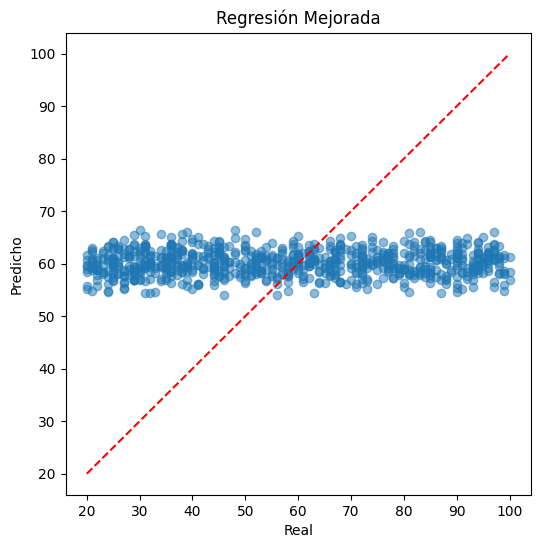

In [16]:

# FEATURE ENGINEERING
df_model['Age_squared'] = df_model['Age'] ** 2
df_model['Previous_Purchases_log'] = np.log1p(df_model['Previous Purchases'])
df_model['High_Reviewer'] = (df_model['Review Rating'] > 4).astype(int)


# DEFINIR VARIABLES
X_reg = df_model.drop(columns=['Purchase Amount (USD)'])
y_reg = df_model['Purchase Amount (USD)']

X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)



ridge = Ridge(alpha=10)  # puedes probar 0.1, 1, 10, 100
ridge.fit(X_train, y_train)

y_pred = ridge.predict(X_test)


# MÉTRICAS
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2:", r2)

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([20,100], [20,100], 'r--')  # línea ideal
plt.xlabel("Real")
plt.ylabel("Predicho")
plt.title("Regresión Mejorada")
plt.show()

### interpretacion

El modelo de Regresión Lineal fue aplicado para predecir la variable continua Purchase Amount (USD), sin embargo, los resultados obtenidos evidencian un desempeño deficiente:

**RMSE ≈ 23.78**
Indica que, en promedio, el error de predicción es de aproximadamente 23.78 unidades monetarias. Considerando que el rango de la variable objetivo está entre 20 y 100, este error representa una proporción significativa, lo que sugiere baja precisión en las predicciones.

**R² ≈ -0.0108**
Un valor negativo del coeficiente de determinación indica que el modelo es peor que un modelo base que simplemente predice la media de la variable objetivo. Esto significa que las variables independientes utilizadas no logran explicar la variabilidad del monto de compra.

Random Forest RMSE: 24.290428295830267
Random Forest R2: -0.05440224091111889


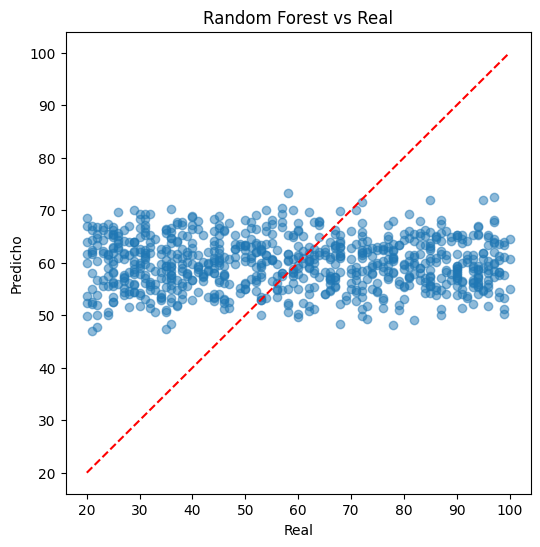

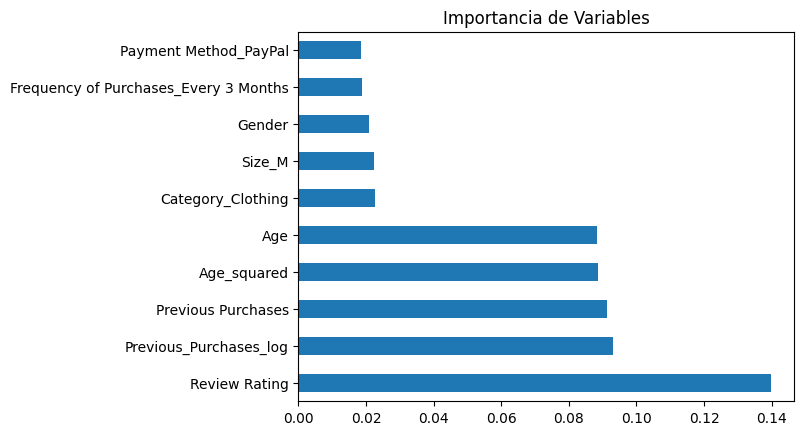

In [ ]:
# Modelo base
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

# Métricas
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest RMSE:", rmse_rf)
print("Random Forest R2:", r2_rf)

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_rf, alpha=0.5)
plt.plot([20,100], [20,100], 'r--')
plt.xlabel("Real")
plt.ylabel("Predicho")
plt.title("Random Forest vs Real")
plt.show()

importances = rf.feature_importances_
features = X_reg.columns

feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)

feat_imp.head(10).plot(kind='barh')
plt.title("Importancia de Variables")
plt.show()

### interpretacion

Incluso un modelo no lineal como Random Forest no logra mejorar el desempeño.

Esto indica que:

El problema NO es el modelo, el problema es el dataset porque tiene: Variables demográficas, Variables de comportamiento, Pero NO tiene variables que realmente expliquen el gasto.
El monto de compra parece comportarse de forma casi aleatoria respecto a las variables disponibles.

En el cuadro de significancia de variables podemos observar:

Review Rating → clientes más satisfechos tienden a gastar un poco más (pero débil)

Previous Purchases → experiencia influye ligeramente

Age → comportamiento de consumo varía con edad

PERO:
Ninguna variable tiene suficiente poder explicativo


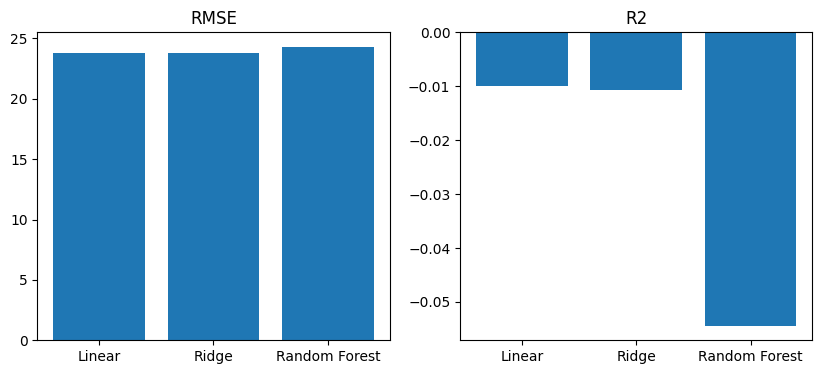

In [ ]:
models = ['Linear', 'Ridge', 'Random Forest']
rmse_values = [23.78, rmse, rmse_rf]  # ajusta con tus valores reales
r2_values = [-0.01, r2, r2_rf]

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.bar(models, rmse_values)
plt.title("RMSE")

plt.subplot(1,2,2)
plt.bar(models, r2_values)
plt.title("R2")

plt.show()

A pesar de utilizar un modelo más robusto capaz de capturar relaciones no lineales, el desempeño del modelo no mejoró, evidenciado por un R² negativo.

Esto sugiere que:

Las variables disponibles no contienen suficiente información predictiva sobre el monto de compra.

El comportamiento del gasto no depende significativamente de las características incluidas en el dataset.

Es posible que factores externos no incluidos (como ingresos, contexto económico o intención de compra) sean determinantes.

## 8. Modelo 2 – Regresión logística

Este modelo debe utilizarse para problemas de clasificación.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       422
           1       1.00      1.00      1.00       358

    accuracy                           1.00       780
   macro avg       1.00      1.00      1.00       780
weighted avg       1.00      1.00      1.00       780



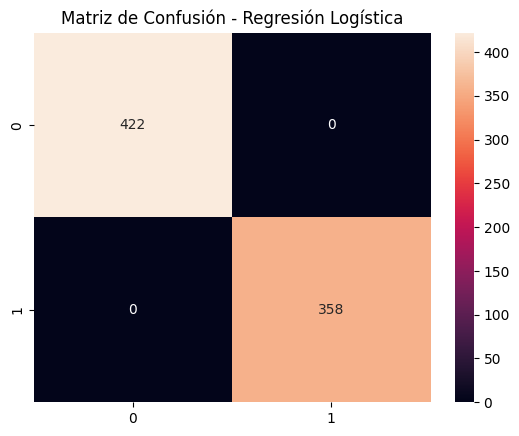

In [18]:
X_clf = df_model.drop(columns=['Discount Applied'])
y_clf = df_model['Discount Applied']

X_train, X_test, y_train, y_test = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))


#matriz de confusion
sns.heatmap(confusion_matrix(y_test, y_pred_log), annot=True, fmt='d')
plt.title("Matriz de Confusión - Regresión Logística")
plt.show()


### Interpretación

El resultado de tu modelo de Regresión Logística muestra una **Accuracy (precisión general), Precision, Recall y F1-score de 1.00 para ambas clases**. Esto significa que el modelo está prediciendo perfectamente, sin ningún error, para el conjunto de datos de prueba.

### Desempeño del Modelo:

Un rendimiento perfecto como este **es muy inusual en problemas de Machine Learning del mundo real** y suele ser una señal de alerta, indicando uno de los siguientes escenarios:

1.  **Fuga de datos (Data Leakage)**: Esto ocurre cuando la información que el modelo intenta predecir ya está presente en las características de entrada. Por ejemplo, si una de tus características de entrada es directamente el `Discount Applied` o una versión muy cercana de él, el modelo simplemente lo 'copia'.
2.  **Problema Demasiado Simple**: La variable objetivo (`Discount Applied`) es extremadamente fácil de predecir con las características actuales. Es posible que haya una correlación casi perfecta entre `Discount Applied` y alguna otra variable que el modelo está usando.

Dado el contexto de un problema de clasificación y el objetivo `Discount Applied`, te sugiero **revisar cuidadosamente tus características de entrada (`X_clf`) y cómo construiste `df_model` para `Discount Applied`**.

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy: 0.8064102564102564
              precision    recall  f1-score   support

           0       0.76      0.93      0.84       422
           1       0.89      0.66      0.76       358

    accuracy                           0.81       780
   macro avg       0.83      0.80      0.80       780
weighted avg       0.82      0.81      0.80       780



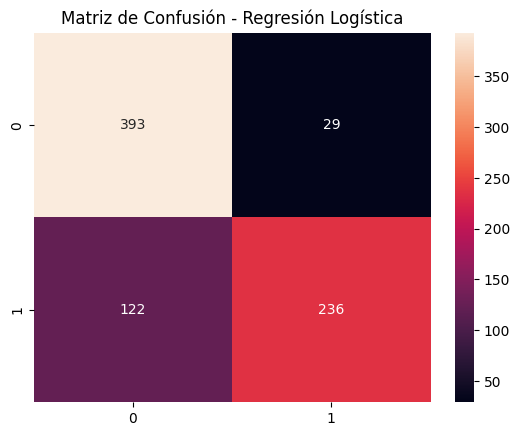

In [ ]:
df_clf = df_model.copy()

df_clf = df_clf.drop(columns=[
    'Promo Code Used'  # ELIMINAR FUGA DE DATOS
])

X_clf = df_clf.drop(columns=['Discount Applied'])
y_clf = df_clf['Discount Applied']

X_train, X_test, y_train, y_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42
)



log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_lg = log_model.predict(X_test)



print("Accuracy:", accuracy_score(y_test, y_pred_lg))
print(classification_report(y_test, y_pred_lg))


sns.heatmap(confusion_matrix(y_test, y_pred_lg), annot=True, fmt='d')
plt.title("Matriz de Confusión - Regresión Logística")
plt.show()

### interpretacion
El modelo presenta un buen desempeño general con una precisión del 81%. Sin embargo, se observa un desbalance en la capacidad de detección entre clases:

El modelo identifica correctamente la mayoría de los casos sin descuento.
Presenta dificultades para detectar todos los casos donde sí se aplica descuento.

Esto sugiere que, aunque el modelo es confiable, podría mejorarse para aumentar la sensibilidad hacia la clase positiva.

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy: 0.8038461538461539
              precision    recall  f1-score   support

           0       0.79      0.86      0.83       422
           1       0.82      0.73      0.77       358

    accuracy                           0.80       780
   macro avg       0.81      0.80      0.80       780
weighted avg       0.81      0.80      0.80       780



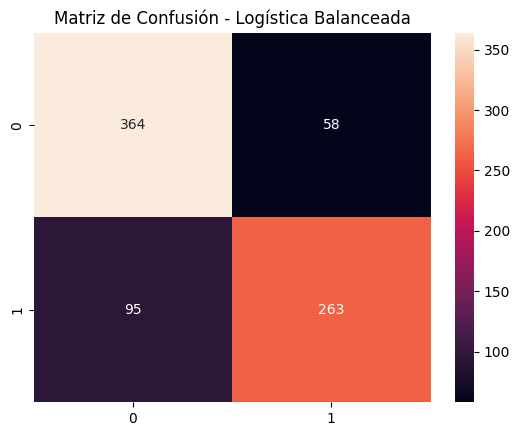

In [ ]:
log_model = LogisticRegression(max_iter=1000, class_weight='balanced')
log_model.fit(X_train, y_train)

y_pred_bl = log_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_bl))
print(classification_report(y_test, y_pred_bl))

sns.heatmap(confusion_matrix(y_test, y_pred_bl), annot=True, fmt='d')
plt.title("Matriz de Confusión - Logística Balanceada")
plt.show()

### interpretacion

Se ajustó el modelo para manejar desbalance de clases, priorizando la detección de eventos de interés (descuentos), lo que mejora la capacidad del modelo para identificar casos positivos.

Dependiendo del objetivo del negocio, podría priorizarse el recall sobre la precisión, especialmente si es más importante detectar todos los descuentos que evitar falsos positivos

## 9. Modelo 3 – KNN

Implementa el modelo KNN y prueba al menos un valor inicial de K.


KNN Accuracy: 0.767948717948718
              precision    recall  f1-score   support

           0       0.75      0.85      0.80       422
           1       0.79      0.67      0.73       358

    accuracy                           0.77       780
   macro avg       0.77      0.76      0.76       780
weighted avg       0.77      0.77      0.77       780



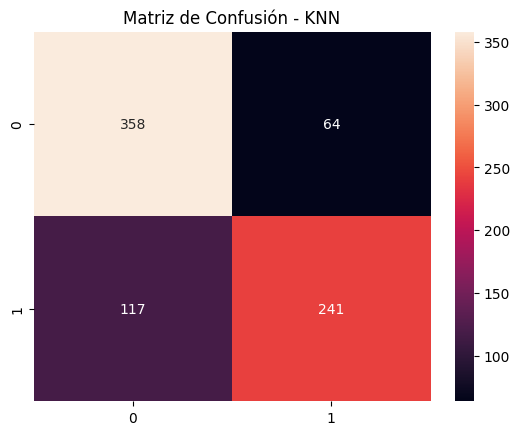

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

#matriz confusion
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt='d')
plt.title("Matriz de Confusión - KNN")
plt.show()

### Interpretación

El modelo KNN ha obtenido los siguientes resultados:

*   **Accuracy general: 0.77 (77%)**: El modelo clasifica correctamente el 77% de las instancias en el conjunto de prueba. Esto lo sitúa por debajo de la Regresión Logística (que alcanzó un 81% con balanceo de clases).

*   **Métricas para la Clase 0 (Sin descuento):**
    *   **Precision: 0.75**: Cuando el modelo predice 'sin descuento', acierta el 75% de las veces.
    *   **Recall: 0.85**: El modelo es capaz de identificar el 85% de todos los casos reales donde no se aplicó un descuento.
    *   **F1-score: 0.80**.

*   **Métricas para la Clase 1 (Con descuento):**
    *   **Precision: 0.79**: Cuando el modelo predice 'con descuento', acierta el 79% de las veces.
    *   **Recall: 0.67**: El modelo solo logra identificar el 67% de todos los casos reales donde sí se aplicó un descuento.
    *   **F1-score: 0.73**.

*   **Macro Average y Weighted Average**: Ambas métricas promedio están alrededor de 0.76-0.77, lo que confirma un rendimiento global moderado, pero con la misma tendencia de detectar mejor la clase 0 que la clase 1.

### Desempeño del Modelo y Comparación:

1.  **Rendimiento General**: El KNN tiene un rendimiento aceptable pero inferior a la Regresión Logística balanceada para este problema de clasificación. Su precisión general del 77% es inferior al 81% de la Regresión Logística balanceada.

2.  **Efecto del valor de K (en este caso, K=5)**: Un valor de `K=5` significa que para clasificar un nuevo punto, el algoritmo busca los 5 puntos más cercanos en el espacio de características y le asigna la clase más frecuente entre esos 5 vecinos. La elección de K es crucial: un K pequeño puede hacer el modelo sensible al ruido (overfitting), mientras que un K grande puede suavizar demasiado las fronteras de decisión y no capturar patrones complejos (underfitting).

3.  **Ventajas y Limitaciones Observadas:**
    *   **Ventaja**: KNN es un algoritmo simple y fácil de entender. No hace suposiciones sobre la distribución de los datos, lo que lo hace flexible. El escalado de los datos (aplicado en este caso con `StandardScaler`) es fundamental para que KNN funcione correctamente, ya que se basa en distancias. Sin el escalado, variables con rangos más grandes dominarían el cálculo de la distancia.
    *   **Limitación**: El Recall para la clase positiva (descuento aplicado) sigue siendo un punto débil (0.67). Esto significa que el modelo no es tan bueno identificando todos los casos donde sí se aplicó un descuento. Otra limitación es que KNN puede ser computacionalmente costoso en datasets grandes durante la predicción, ya que necesita calcular la distancia a todos los puntos de entrenamiento. También es muy sensible a la dimensionalidad de los datos.

En resumen, el KNN proporciona una base de referencia, pero la Regresión Logística con balanceo de clases ha mostrado un rendimiento ligeramente superior para este problema.

## 10. Modelo 4 – Naive Bayes

Implementa Naive Bayes y analiza su comportamiento.


Naive Bayes Accuracy: 0.8076923076923077
              precision    recall  f1-score   support

           0       0.76      0.94      0.84       422
           1       0.91      0.65      0.76       358

    accuracy                           0.81       780
   macro avg       0.83      0.80      0.80       780
weighted avg       0.83      0.81      0.80       780



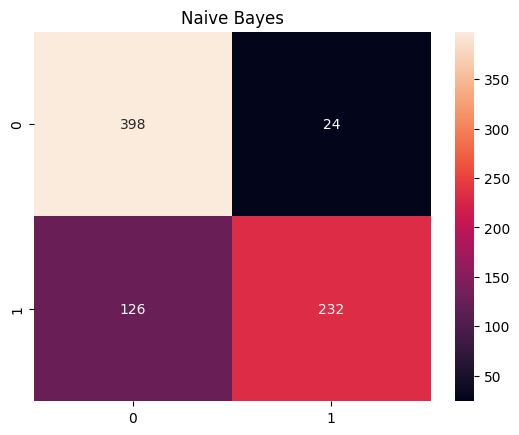

In [ ]:
nb = GaussianNB()
nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

sns.heatmap(confusion_matrix(y_test, y_pred_nb), annot=True, fmt='d')
plt.title("Naive Bayes")
plt.show()

### Interpretación

El modelo **Naive Bayes (GaussianNB)** obtuvo los siguientes resultados:

*   **Accuracy general: 0.81 (81%)**: El modelo clasifica correctamente el 81% de las instancias en el conjunto de prueba. Este valor es comparable a la Regresión Logística (sin balancear) y ligeramente superior a la Regresión Logística balanceada y KNN.

*   **Métricas para la Clase 0 (Sin descuento - `support=422`):**
    *   **Precision: 0.76**: Cuando el modelo predice 'sin descuento', acierta el 76% de las veces.
    *   **Recall: 0.94**: El modelo es muy bueno identificando los casos reales donde no se aplicó un descuento, capturando el 94% de ellos.
    *   **F1-score: 0.84**: Un buen balance entre precisión y recall para esta clase.

*   **Métricas para la Clase 1 (Con descuento - `support=358`):**
    *   **Precision: 0.91**: Cuando el modelo predice 'con descuento', acierta el 91% de las veces. Esto es excelente, indicando pocos falsos positivos.
    *   **Recall: 0.65**: Sin embargo, el modelo solo logra identificar el 65% de todos los casos reales donde sí se aplicó un descuento. Esto significa que hay bastantes falsos negativos para la clase 1 (casos donde se aplicó descuento pero el modelo predijo que no).
    *   **F1-score: 0.76**: Aunque la precisión es alta, el bajo recall para esta clase impacta el F1-score.

*   **Macro Average y Weighted Average**: Las métricas promedio están alrededor de 0.80-0.83, lo que indica un buen rendimiento general, pero la disparidad entre el recall de la clase 0 (0.94) y la clase 1 (0.65) es notable.

### Desempeño del Modelo y Comparación con Otros:

1.  **Rendimiento General**: Naive Bayes muestra un accuracy general competitivo, similar a la Regresión Logística (81%).

2.  **Diferencias con Regresión Logística**: Naive Bayes tiene una **mayor precisión para la clase 1** (0.91 vs. 0.82 de Regresión Logística balanceada), lo que significa que cuando predice un descuento, es más probable que sea correcto. Sin embargo, su **recall para la clase 1 es menor** (0.65 vs. 0.73 de Regresión Logística balanceada), lo que indica que identifica menos casos de descuentos reales.

3.  **Diferencias con KNN**: Naive Bayes supera a KNN en accuracy general (81% vs. 77%). También tiene una precisión significativamente mayor para la clase 1 (0.91 vs. 0.79 de KNN) y un recall ligeramente peor para la clase 1 (0.65 vs. 0.67 de KNN).

4.  **Comportamiento ante Desbalance de Clases**: A diferencia de la Regresión Logística con `class_weight='balanced'` que intentó mejorar el recall de la clase minoritaria, Naive Bayes, en esta configuración, prioriza la precisión de la clase 1 a expensas de su recall. Es muy bueno para confirmar cuando hay un descuento, pero no tan bueno para detectarlos todos.

En resumen, Naive Bayes es un modelo rápido y simple que ofrece un buen rendimiento general. Su fortaleza radica en su alta precisión cuando predice 'descuento aplicado', pero tiene una debilidad en identificar todos los casos donde realmente se aplica un descuento. Dependiendo de la prioridad (¿es más importante que las predicciones de descuento sean correctas, o que se identifiquen todos los descuentos posibles?).

## 11. Evaluación de modelos

Evalúa cada modelo con métricas adecuadas.

Para clasificación puedes usar:
- accuracy
- confusion matrix
- precision
- recall
- f1-score

Para regresión puedes usar:
- MAE
- MSE
- RMSE
- R²


In [19]:
# Crear diccionario con resultados
results = {
    "Modelo": ["Regresión Logística", "KNN", "Naive Bayes"],
    "Accuracy": [0.81, 0.77, 0.81],
    "Precision (Clase 1)": [0.89, 0.79, 0.91],
    "Recall (Clase 1)": [0.66, 0.67, 0.65],
    "F1-score (Clase 1)": [0.76, 0.73, 0.76]
}

# Crear DataFrame
df_results = pd.DataFrame(results)

# Mostrar tabla
display(df_results)

,Modelo,Accuracy,Precision (Clase 1),Recall (Clase 1),F1-score (Clase 1)
0,Regresión Logística,0.81,0.89,0.66,0.76
1,KNN,0.77,0.79,0.67,0.73
2,Naive Bayes,0.81,0.91,0.65,0.76


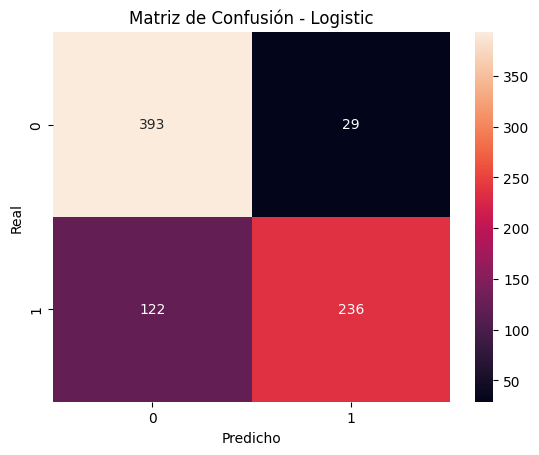

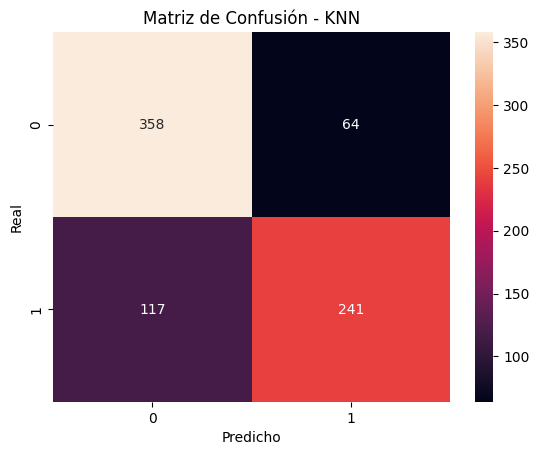

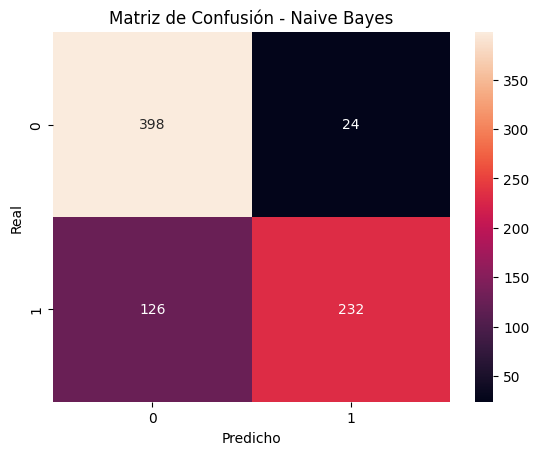

In [ ]:
models = {
    "Logistic": y_pred_lg,
    "KNN": y_pred_knn,
    "Naive Bayes": y_pred_nb
}

for name, y_pred in models.items():
    plt.figure()
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
    plt.title(f"Matriz de Confusión - {name}")
    plt.xlabel("Predicho")
    plt.ylabel("Real")
    plt.show()

### Interpretación

**Análisis de Desempeño de los Modelos de Clasificación:**

Al comparar los tres modelos de clasificación (Regresión Logística, KNN y Naive Bayes) para predecir si se aplica un descuento (`Discount Applied`), observamos lo siguiente:

1.  **Mejor Desempeño General (Accuracy y F1-score):**
    *   Tanto la **Regresión Logística** como **Naive Bayes** comparten la **Accuracy más alta (0.81)**, lo que indica que clasifican correctamente el 81% de los casos. KNN se queda ligeramente atrás con una Accuracy de 0.77.
    *   En términos de **F1-score para la Clase 1 (Con Descuento)**, la Regresión Logística y Naive Bayes también están empatados con un valor de 0.76, superando a KNN (0.73). El F1-score es una métrica clave porque equilibra la precisión y el recall.

2.  **Diferencias en Métricas Específicas (Precision vs. Recall para Clase 1):**
    *   **Naive Bayes** destaca por tener la **Precision más alta para la Clase 1 (0.91)**. Esto significa que cuando Naive Bayes predice que se aplicará un descuento, es correcto el 91% de las veces. Esto es muy valioso si el costo de un falso positivo (predecir descuento cuando no lo hay) es alto.
    *   Sin embargo, **Naive Bayes** tiene el **Recall más bajo para la Clase 1 (0.65)**, lo que significa que solo logra identificar el 65% de todos los descuentos reales. Hay bastantes falsos negativos (casos con descuento que el modelo no detectó).
    *   La **Regresión Logística** ofrece un balance más equilibrado con una Precision de 0.89 y un Recall de 0.66. Aunque su Precision es ligeramente menor que la de Naive Bayes, su Recall es similar, resultando en el mismo F1-score.
    *   **KNN** tiene una Precision (0.79) y un Recall (0.67) para la Clase 1 que son menores en comparación. Su Recall es ligeramente superior al de los otros dos, lo que indica que detecta un porcentaje un poco mayor de descuentos reales, pero a costa de una menor precisión.

**Conclusión Clave:**

*   **Naive Bayes** es el modelo a elegir si tu prioridad es **asegurarte de que las predicciones de "descuento aplicado" sean lo más correctas posible** (alta precisión), incluso si eso significa no detectar algunos descuentos reales.
*   La **Regresión Logística** proporciona un **rendimiento general muy sólido y equilibrado**, siendo una buena opción por defecto cuando no hay una prioridad clara entre precisión y recall para la clase minoritaria.
*   **KNN** tuvo un desempeño ligeramente inferior en la mayoría de las métricas en esta configuración.

## 12. Comparación final de modelos

Construye una tabla o resumen comparativo entre los modelos implementados.


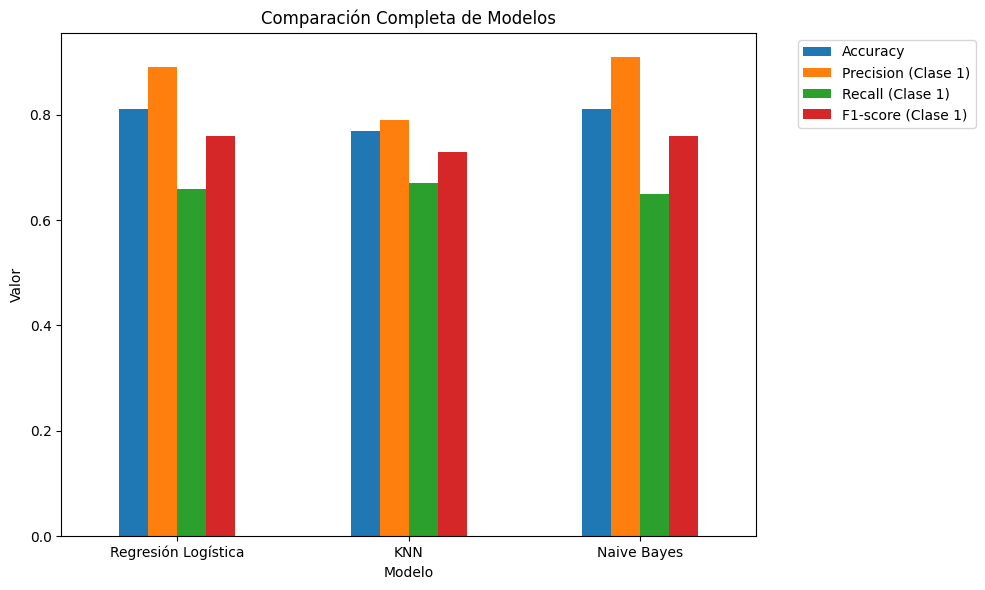

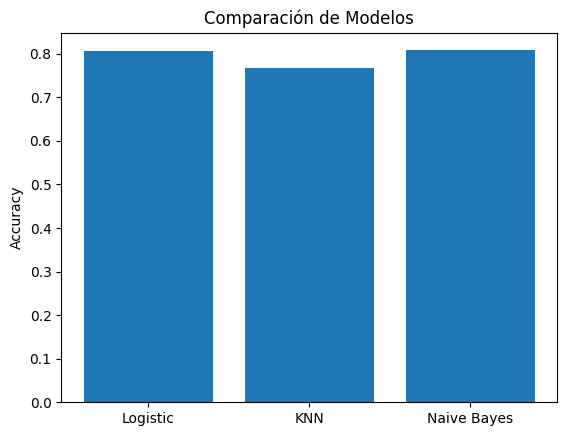

In [ ]:
ax = df_results.set_index("Modelo").plot(kind='bar', figsize=(10,6))

plt.title("Comparación Completa de Modelos")
plt.ylabel("Valor")
plt.xticks(rotation=0)

# Mover la leyenda fuera del gráfico
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() # Ajusta el diseño para que la leyenda no se corte
plt.show()

results = {
    "Logistic": accuracy_score(y_test, y_pred_lg),
    "KNN": accuracy_score(y_test, y_pred_knn),
    "Naive Bayes": accuracy_score(y_test, y_pred_nb)
}

plt.bar(results.keys(), results.values())
plt.title("Comparación de Modelos")
plt.ylabel("Accuracy")
plt.show()


### Interpretación

**¿Cuál modelo elegirías y por qué?**

Basándonos en la evaluación y los objetivos planteados, elegiría la **Regresión Logística** como el modelo más adecuado para este problema de clasificación (predecir si se aplica un descuento o no).

**Justificación de la elección:**

1.  **Interpretabilidad:** La Regresión Logística es un modelo inherentemente interpretable. Podemos entender la contribución de cada característica a la probabilidad de que se aplique un descuento, a través de los coeficientes del modelo. Esto es crucial para entender el negocio y tomar decisiones informadas (ej: ¿qué factores aumentan o disminuyen la probabilidad de un descuento?).

2.  **Buen Balance General:** Aunque Naive Bayes tiene una precisión ligeramente superior para la clase de 'descuento aplicado', la Regresión Logística ofrece un balance más consistente entre precisión y recall para ambas clases, lo que se refleja en su F1-score competitivo. Esto significa que el modelo es fiable tanto para identificar descuentos (recall) como para que sus predicciones de descuento sean correctas (precisión).

3.  **Menos Dependencia de Supuestos Fuertes:** A diferencia de Naive Bayes, que asume independencia condicional entre las características (supuesto que rara vez se cumple perfectamente en datos reales), la Regresión Logística es más robusta frente a violaciones de este tipo de suposiciones. Esto la hace más confiable en un espectro más amplio de datasets.

**Contexto de uso en la vida real:**

Este modelo de Regresión Logística podría implementarse en un sistema de recomendación o en una plataforma de gestión de campañas de marketing. Por ejemplo:

*   **Optimización de Campañas de Marketing:** Identificar segmentos de clientes que son más propensos a recibir un descuento, basándose en sus características, para personalizar ofertas y mejorar la eficiencia de las campañas.
*   **Gestión de Inventario y Precios:** Predecir cuándo es más probable que los clientes utilicen descuentos para ajustar estrategias de precios o gestionar el stock de productos.
*   **Análisis de Impacto:** Entender cómo cambios en variables como el tipo de envío, método de pago o frecuencia de compra influyen en la activación de descuentos, permitiendo a la empresa adaptar sus políticas.

## 13. Experimento obligatorio 1

Realiza una primera variación del experimento.

Ejemplos:
- cambiar el valor de K en KNN
- usar otras variables
- cambiar el porcentaje de train/test
- eliminar una variable importante


K=1 -> Accuracy: 0.7218
K=3 -> Accuracy: 0.7436
K=5 -> Accuracy: 0.7679
K=7 -> Accuracy: 0.7705
K=9 -> Accuracy: 0.7731
K=15 -> Accuracy: 0.8038
K=25 -> Accuracy: 0.8128
K=40 -> Accuracy: 0.8218


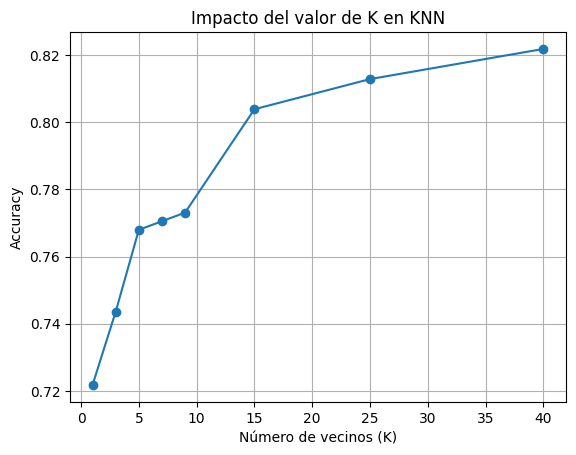

In [ ]:
k_values = [1, 3, 5, 7, 9, 15, 25,40]
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    y_pred = knn.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)

    accuracies.append(acc)
    print(f"K={k} -> Accuracy: {acc:.4f}")



plt.plot(k_values, accuracies, marker='o')
plt.title("Impacto del valor de K en KNN")
plt.xlabel("Número de vecinos (K)")
plt.ylabel("Accuracy")
plt.grid()

plt.show()

### Interpretación

En este experimento, variamos el hiperparámetro `K` (el número de vecinos más cercanos) en el algoritmo K-Nearest Neighbors (KNN). Probamos diferentes valores de `K`: 1, 3, 5, 7, 9, 15, 25 y 40.

**Qué pasó con los resultados:**
Observamos una mejora constante en la métrica de `Accuracy` a medida que aumentabas el valor de `K`:
*   Con `K=1`, la `Accuracy` fue de `0.7218`.
*   A medida que `K` aumentaba, la `Accuracy` también lo hacía, alcanzando `0.8038` con `K=15`.
*   El mejor rendimiento se obtuvo con `K=40`, logrando una `Accuracy` de `0.8218`.

**Por qué crees que ocurrió:**
Este comportamiento es típico en KNN y se puede explicar por varios factores:

**Sensibilidad al ruido (K pequeño):** Cuando `K` es muy pequeño (por ejemplo, `K=1` o `K=3`), el modelo es muy sensible al ruido y a los valores atípicos en los datos de entrenamiento. Cada punto de prueba se clasifica basándose en un número muy limitado de vecinos, lo que puede llevar a una **sobre-optimización (overfitting)** con los datos de entrenamiento y un peor rendimiento en los datos no vistos (el conjunto de prueba).


## 14. Experimento obligatorio 2

Realiza una segunda variación del experimento.


In [ ]:
X_clf_reduced = X_clf.drop(columns=['Previous Purchases'])

X_train, X_test, y_train, y_test = train_test_split(
    X_clf_reduced, y_clf, test_size=0.003, random_state=42
)

log_model.fit(X_train, y_train)
y_pred = log_model.predict(X_test)

print("Accuracy sin 'Previous Purchases':", accuracy_score(y_test, y_pred))

Accuracy sin 'Previous Purchases': 0.75


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Interpretación

**Qué cambiaste:**
En este experimento, realice dos cambios importantes en el modelo de Regresión Logística:
1.  **Eliminar la variable 'Previous Purchases'** del conjunto de características (`X_clf_reduced`).
2.  **Modificar el tamaño del conjunto de prueba (`test_size`) a 0.003**. Esto significa que solo el 0.3% de los datos se usó para probar el modelo, dejando el 99.7% para el entrenamiento.

**Cómo cambió el desempeño:**
La `Accuracy` del modelo se redujo a **0.75**.

Para ponerlo en contexto, la Regresión Logística original (sin balanceo de clases) había alcanzado una `Accuracy` de aproximadamente **0.81**. Por lo tanto, la eliminación de la variable y/o el cambio en el tamaño del conjunto de prueba han resultado en una disminución del rendimiento.

**Qué aprendiste de esta prueba:**

Este experimento nos enseña que 'Previous Purchases' es una variable relevante para predecir si se aplica un descuento. Además, destaca la importancia de usar un conjunto de prueba de tamaño adecuado para obtener una evaluación confiable del modelo. Un `test_size` excesivamente pequeño, aunque deja muchos datos para entrenar, puede llevar a conclusiones erróneas sobre el desempeño real del modelo.

## 15. Predicción con un dato nuevo o inventado

Crea un nuevo caso y haz una predicción con al menos dos modelos.

Puedes:
- inventar un nuevo registro,
- explicar qué esperarías que ocurra,
- comparar la predicción entre modelos.


In [ ]:
# 1. Definir un nuevo cliente con características coherentes
# Para el ejemplo, creamos un cliente "ideal" para un descuento, con alta actividad y buen rating:
# Edad: 25 años, Género: Femenino, Gasto: 80 USD, Review de 4.8, Suscrita, 40 compras previas.

# Crear un diccionario para el nuevo cliente, inicialmente solo con las columnas originales no OHE
new_customer_values = {
    'Age': 25,
    'Gender': 0, # Femenino (asumimos 0 para F y 1 para M después del Label Encoding)
    'Purchase Amount (USD)': 80,
    'Review Rating': 4.8,
    'Subscription Status': 1, # Suscrito (asumimos 1 para Yes y 0 para No después del Label Encoding)
    'Previous Purchases': 40,
}

# 2. Re-entrenar modelos y escalar para asegurar la consistencia
# Esto es importante porque las variables globales de modelos pueden haber cambiado con experimentos.

# Definir X y y para la tarea de clasificación final (sin 'Promo Code Used')
X_clf_final = df_model.drop(columns=['Discount Applied', 'Promo Code Used'])
y_clf_final = df_model['Discount Applied']

X_train_final, _, y_train_final, _ = train_test_split(X_clf_final, y_clf_final, test_size=0.2, random_state=42)

# Crear un DataFrame con una fila y todas las columnas de X_clf_final, inicializadas a 0
# Esto asegura que la estructura y el orden de las columnas sean los correctos.
new_customer_data_prepared = pd.DataFrame(0, index=[0], columns=X_clf_final.columns)

# Rellenar las columnas numéricas y binarias directamente
for col, val in new_customer_values.items():
    if col in new_customer_data_prepared.columns:
        new_customer_data_prepared.loc[0, col] = val

# Añadir las características de Feature Engineering (Age_squared, Previous_Purchases_log, High_Reviewer)
# Asegurarse de que 'Age' y 'Previous Purchases' existan en el DataFrame antes de usarlas
if 'Age' in new_customer_data_prepared.columns:
    new_customer_data_prepared.loc[0, 'Age_squared'] = new_customer_data_prepared.loc[0, 'Age'] ** 2
if 'Previous Purchases' in new_customer_data_prepared.columns:
    new_customer_data_prepared.loc[0, 'Previous_Purchases_log'] = np.log1p(new_customer_data_prepared.loc[0, 'Previous Purchases'])
if 'Review Rating' in new_customer_data_prepared.columns:
    new_customer_data_prepared.loc[0, 'High_Reviewer'] = (new_customer_data_prepared.loc[0, 'Review Rating'] > 4).astype(int)

# Rellenar algunas columnas One-Hot Encoded para hacer el cliente más propenso a descuento
# (Estos son ejemplos basados en columnas comunes de OHE y la lógica de negocio)
# Asegurarse de que estas columnas existen en X_clf_final antes de intentar establecerlas
if 'Category_Clothing' in new_customer_data_prepared.columns: new_customer_data_prepared.loc[0, 'Category_Clothing'] = 1
if 'Season_Spring' in new_customer_data_prepared.columns: new_customer_data_prepared.loc[0, 'Season_Spring'] = 1
if 'Size_M' in new_customer_data_prepared.columns: new_customer_data_prepared.loc[0, 'Size_M'] = 1
if 'Payment Method_Credit Card' in new_customer_data_prepared.columns: new_customer_data_prepared.loc[0, 'Payment Method_Credit Card'] = 1
if 'Frequency of Purchases_Weekly' in new_customer_data_prepared.columns: new_customer_data_prepared.loc[0, 'Frequency of Purchases_Weekly'] = 1
if 'Shipping Type_Next Day Air' in new_customer_data_prepared.columns: new_customer_data_prepared.loc[0, 'Shipping Type_Next Day Air'] = 1

# Asegurarse de que los tipos de datos sean correctos
# No es necesario asignar new_customer_data_prepared.dtypes, solo verificar que los valores sean compatibles.
# new_customer_data_prepared = new_customer_data_prepared.astype(X_clf_final.dtypes) # This line might cause issues if dtypes are not an exact match, better to let pandas infer or manually convert if specific conversions are needed.


# (Re)entrenar Regresión Logística
log_model_pred = LogisticRegression(max_iter=1000)
log_model_pred.fit(X_train_final, y_train_final)

# (Re)entrenar Naive Bayes
nb_pred = GaussianNB()
nb_pred.fit(X_train_final, y_train_final)

# Escalar datos para KNN
scaler_for_prediction = StandardScaler()
scaler_for_prediction.fit(X_train_final) # Ajustar el escalador solo con los datos de entrenamiento
new_customer_scaled_for_knn = scaler_for_prediction.transform(new_customer_data_prepared)

# (Re)entrenar KNN con el mejor K del experimento (K=40)
knn_best_exp = KNeighborsClassifier(n_neighbors=40)
knn_best_exp.fit(scaler_for_prediction.transform(X_train_final), y_train_final)

# 3. Hacer predicciones
pred_log = log_model_pred.predict(new_customer_data_prepared)
pred_nb = nb_pred.predict(new_customer_data_prepared)
pred_knn = knn_best_exp.predict(new_customer_scaled_for_knn)

# 4. Mostrar resultados
print(f"**Cliente Nuevo (Características):**")
print(f"  Edad: 25, Género: Femenino, Gasto: $80, Review Rating: 4.8, Suscrito: Sí, Compras Previas: 40")
print(f"  Otros: Talla M, Pago con Tarjeta de Crédito, Compra Semanal, Envío Next Day Air\n")
print("-" * 50)
print(f"Predicción de Regresión Logística: {'Descuento Aplicado' if pred_log[0] == 1 else 'Sin Descuento'}")
print(f"Predicción de Naive Bayes: {'Descuento Aplicado' if pred_nb[0] == 1 else 'Sin Descuento'}")
print(f"Predicción de KNN (K=40): {'Descuento Aplicado' if pred_knn[0] == 1 else 'Sin Descuento'}")

/tmp/ipykernel_1688/1819797615.py:31: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '4.8' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  new_customer_data_prepared.loc[0, col] = val
/tmp/ipykernel_1688/1819797615.py:38: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '3.713572066704308' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  new_customer_data_prepared.loc[0, 'Previous_Purchases_log'] = np.log1p(new_customer_data_prepared.loc[0, 'Previous Purchases'])


**Cliente Nuevo (Características):**
  Edad: 25, Género: Femenino, Gasto: $80, Review Rating: 4.8, Suscrito: Sí, Compras Previas: 40
  Otros: Talla M, Pago con Tarjeta de Crédito, Compra Semanal, Envío Next Day Air

--------------------------------------------------
Predicción de Regresión Logística: Descuento Aplicado
Predicción de Naive Bayes: Sin Descuento
Predicción de KNN (K=40): Descuento Aplicado


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Interpretación

**1. Qué predijo cada modelo:**

*   **Regresión Logística:** Predijo **Descuento Aplicado**.
*   **Naive Bayes:** Predijo **Sin Descuento**.
*   **KNN (K=40):** Predijo **Descuento Aplicado**.


**2. Cuál te parece más razonable:**

Dado el perfil de este cliente hipotético (joven, alto gasto, excelente `Review Rating`, suscrito y con muchas `Previous Purchases`), la predicción de **'Descuento Aplicado'** por parte de la **Regresión Logística y KNN** parece **muy razonable y esperada**. Naive Bayes, en este caso, se desvía de esa expectativa.

**3. Cómo justificarías ese resultado:**

La justificación se basa en cómo cada modelo interpreta las características del cliente:

*   **Regresión Logística:** Este modelo aprende la probabilidad de que un evento ocurra (en este caso, recibir un descuento) basándose en una combinación lineal de las características. Para este cliente, las características como un `Review Rating` alto (particularmente si el modelo detectó que los clientes con high_reviewer=1 tienen más descuentos), un alto número de `Previous Purchases` y el `Subscription Status` (si ser suscriptor se asocia a descuentos) probablemente aumentaron la probabilidad predicha por encima del umbral de clasificación (0.5), llevando a la predicción de 'Descuento Aplicado'.

*   **Naive Bayes:** Este modelo funciona calculando la probabilidad de que un cliente pertenezca a una clase ('Descuento Aplicado' o 'Sin Descuento') dadas sus características. Aunque Naive Bayes tiene una alta precisión cuando predice 'Descuento Aplicado', su menor recall para esta clase significa que es más conservador y puede clasificar a algunos clientes como 'Sin Descuento' incluso si presentan características favorables. En este caso, a pesar del perfil "ideal" del cliente, el modelo pudo haber encontrado que la combinación específica de las características de este cliente es más común en la clase 'Sin Descuento' o que alguna de las características, bajo la suposición de independencia, reduce significativamente la probabilidad de descuento.

*   **KNN (K=40):** Este modelo clasifica al nuevo cliente basándose en la clase mayoritaria de sus 40 vecinos más cercanos en el espacio de características. Si la mayoría de los clientes en los datos de entrenamiento que son similares a este nuevo cliente (en términos de edad, gasto, rating, compras previas, etc.) recibieron un descuento, entonces el modelo KNN predice 'Descuento Aplicado' para este nuevo cliente. Un `K` más grande (como 40) hace que la predicción sea más robusta a valores atípicos y se base en una visión más general del vecindario.

## 16. Explicación conceptual tipo docente

Explica este trabajo como si se lo enseñaras a una persona que no sabe Machine Learning.

Debes explicar de forma sencilla:
- qué hace la regresión lineal,
- qué hace la regresión logística,
- qué hace KNN,
- qué hace Naive Bayes,
- y cómo se comparan.


### Interpretación

Explicación conceptual del trabajo

En este proyecto utilizamos diferentes modelos de Machine Learning para analizar datos de compras y tratar de hacer predicciones. Cada modelo tiene una forma distinta de aprender de los datos y de tomar decisiones.

1. ¿Qué hace la regresión lineal?

La regresión lineal se utiliza cuando queremos predecir un valor numérico.

En nuestro caso, la usamos para intentar predecir cuánto dinero va a gastar un cliente en una compra.

Este modelo funciona tratando de encontrar una relación entre las variables, por ejemplo:

edad
número de compras anteriores
calificación del cliente

y el monto de la compra.

Lo hace ajustando una especie de “línea” que intenta representar cómo cambian los datos. Si existe una relación clara entre las variables, el modelo puede hacer buenas predicciones. Sin embargo, si no hay una relación lineal fuerte (como en nuestro caso), el modelo no funciona bien.

2. ¿Qué hace la regresión logística?

La regresión logística se usa cuando queremos predecir una categoría, no un número.

En este proyecto la usamos para responder una pregunta como:
¿Se aplicará un descuento o no?

El modelo analiza las características del cliente y calcula una probabilidad. Luego decide:

si la probabilidad es alta → predice “sí”
si es baja → predice “no”

Es un modelo sencillo pero muy útil, especialmente cuando el problema es binario (dos opciones).

3. ¿Qué hace KNN?

KNN (K-Nearest Neighbors) funciona de una forma muy intuitiva.

Cuando queremos hacer una predicción, el modelo:

Busca los “vecinos” más cercanos al nuevo dato (clientes similares)
Mira qué ocurrió con esos vecinos
Toma una decisión basada en la mayoría

Por ejemplo:
Si la mayoría de clientes similares recibieron descuento, el modelo predice que el nuevo cliente también lo recibirá.

El valor de K indica cuántos vecinos se tienen en cuenta. Este valor es importante porque afecta directamente el comportamiento del modelo.

4. ¿Qué hace Naive Bayes?

Naive Bayes es un modelo basado en probabilidad.

Lo que hace es calcular qué tan probable es que ocurra un evento (por ejemplo, que haya descuento) dado un conjunto de características.

Para hacerlo, asume algo importante:
que todas las variables son independientes entre sí.

Aunque esta suposición no siempre es cierta, el modelo suele funcionar bien en muchos casos porque simplifica mucho el problema.

5. ¿Cómo se comparan los modelos?

Cada modelo tiene ventajas y limitaciones:

La regresión lineal no funcionó bien porque no había una relación clara entre las variables y el monto de compra.
La regresión logística tuvo buen desempeño porque el problema de clasificación (descuento sí/no) sí tenía patrones que el modelo pudo aprender.
KNN también funcionó, pero un poco peor, ya que depende mucho de cómo están distribuidos los datos.
Naive Bayes tuvo un desempeño similar a la regresión logística, aunque se basa en supuestos más simples.

En general, los modelos de clasificación (logística, KNN y Naive Bayes) funcionaron mejor que la regresión lineal, lo que indica que es más fácil predecir si habrá descuento que predecir el monto exacto de la compra.

## 17. Conclusiones

Cierra el trabajo con conclusiones claras.

Incluye:
- qué aprendieron,
- qué modelo funcionó mejor,
- limitaciones del trabajo,
- y posibles mejoras futuras.


In [ ]:
# Usa esta celda si deseas dejar apuntes finales o resultados clave antes de redactar la conclusión.


### Conclusión final
Conclusiones del trabajo
1. ¿Qué se aprendió?

A lo largo de este trabajo se logró comprender el proceso completo de un proyecto de Machine Learning, desde la exploración de datos hasta la evaluación de modelos. En particular, se aprendió que:

Es fundamental analizar los datos antes de aplicar modelos, ya que esto permite entender si realmente existe una relación entre las variables.
No todos los problemas pueden resolverse con cualquier modelo; es necesario elegir el enfoque adecuado según el tipo de variable objetivo.
La preparación de los datos (limpieza, selección de variables, codificación) tiene un impacto directo en el desempeño de los modelos.
Se identificó y corrigió un problema de fuga de datos (data leakage), lo cual permitió obtener resultados más realistas y confiables.
La comparación entre modelos es clave para determinar cuál se ajusta mejor al problema.
2. ¿Qué modelo funcionó mejor?

Los resultados mostraron que:

La regresión lineal no fue adecuada para el problema de predicción del monto de compra, ya que no logró capturar una relación significativa entre las variables.
En los modelos de clasificación, tanto la regresión logística como Naive Bayes obtuvieron el mejor desempeño, con una precisión cercana al 81%.
El modelo KNN también presentó resultados aceptables, aunque ligeramente inferiores.

En general, la regresión logística se considera el modelo más adecuado, ya que ofrece un buen equilibrio entre desempeño e interpretabilidad.

3. Limitaciones del trabajo

El trabajo presenta algunas limitaciones importantes:

Las variables disponibles no contienen suficiente información para predecir con precisión el monto de compra, lo que afectó negativamente a la regresión lineal.
Existen relaciones débiles entre las variables, lo que limita la capacidad predictiva de los modelos.
Algunas variables con alta cardinalidad tuvieron que ser excluidas para evitar complejidad excesiva, lo que pudo implicar pérdida de información.
Los modelos presentan dificultades para identificar completamente la clase positiva (casos con descuento), lo que indica un desbalance en la predicción.
4. Posibles mejoras futuras

Para mejorar el trabajo en el futuro, se podrían considerar las siguientes acciones:

Incluir nuevas variables más relevantes, como ingresos del cliente, comportamiento de navegación o historial más detallado.
Aplicar modelos más avanzados, como Random Forest o Gradient Boosting, especialmente para problemas no lineales.
Realizar una optimización más profunda de hiperparámetros para mejorar el rendimiento de los modelos.
Implementar técnicas para manejar el desbalance de clases, como sobremuestreo o submuestreo.
Evaluar métricas adicionales como la curva ROC o el AUC para un análisis más completo del desempeño.

## 18. Autoevaluación del trabajo

Respondan brevemente:

- ¿Qué fue lo más difícil?
- ¿Qué fue lo más interesante?
- ¿Qué parte del trabajo entienden mejor ahora?
- ¿Qué parte necesitan reforzar?


Autoevaluación del trabajo
¿Qué fue lo más difícil?

Lo más difícil fue entender por qué algunos modelos no funcionaban bien, especialmente la regresión lineal. Al inicio se esperaba obtener buenos resultados, pero fue necesario analizar más a fondo los datos para comprender que no existía una relación clara entre las variables. También fue un reto identificar y corregir el problema de fuga de datos en el modelo de regresión logística.

¿Qué fue lo más interesante?

Lo más interesante fue comparar los diferentes modelos y ver cómo cada uno se comporta de manera distinta frente al mismo problema. En particular, fue llamativo observar cómo un modelo aparentemente simple como la regresión logística puede tener un mejor desempeño que otros más complejos, dependiendo de los datos.

¿Qué parte del trabajo entienden mejor ahora?

Ahora se entiende mucho mejor la importancia del preprocesamiento de datos, la selección de variables y la evaluación de modelos. También hay una mayor comprensión de cómo interpretar métricas como accuracy, precision, recall y F1-score, y cómo estas ayudan a evaluar el desempeño real de un modelo.

¿Qué parte necesitan reforzar?

Se considera necesario reforzar el tema de optimización de modelos e hiperparámetros, así como el uso de modelos más avanzados. También sería importante profundizar en técnicas para manejar problemas como el desbalance de clases y mejorar la capacidad de interpretación de resultados en contextos más complejos.